# Lecture 17 - Exercise - Explore the Ia Supernova dataset

In [ ]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

import os
import corner
import emcee
import numpy                        as np
import matplotlib.pyplot            as plt
import matplotlib                   as mpl
from   matplotlib                   import rc
from   mycolorpy                    import colorlist as mcp
from   numpy.random                 import default_rng
from   sys                          import stdout
from   scipy                        import stats, integrate, special
from   astroML                      import stats as astroMLstats
from   astroML.datasets             import generate_mu_z
from   astroML.linear_model         import PolynomialRegression, BasisFunctionRegression, NadarayaWatson
from   astropy.visualization.hist   import hist  as fancyhist
from   astropy.cosmology            import Planck15, LambdaCDM
from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap, TSNE
from   sklearn.cluster              import KMeans
from   sklearn.neighbors            import KNeighborsClassifier
from   sklearn.metrics              import confusion_matrix, accuracy_score
from   sklearn.model_selection      import train_test_split, learning_curve, GridSearchCV, cross_val_predict
from   sklearn.mixture              import GaussianMixture
from   sklearn.decomposition        import PCA, NMF, FastICA
# from   sklearn.linear_model         import LogisticRegression, LinearRegression

#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

WARNING (theano.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (theano.configdefaults): g++ not detected ! Theano will be unable to execute optimized C-implementations (for both CPU and GPU) and will default to Python implementations. Performance will be severely degraded. To remove this warning, set Theano flags cxx to an empty string.
WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


d:\Documents\University\Magistrale\Statistics\GitHub\working


# Loading data and first quick visualizations

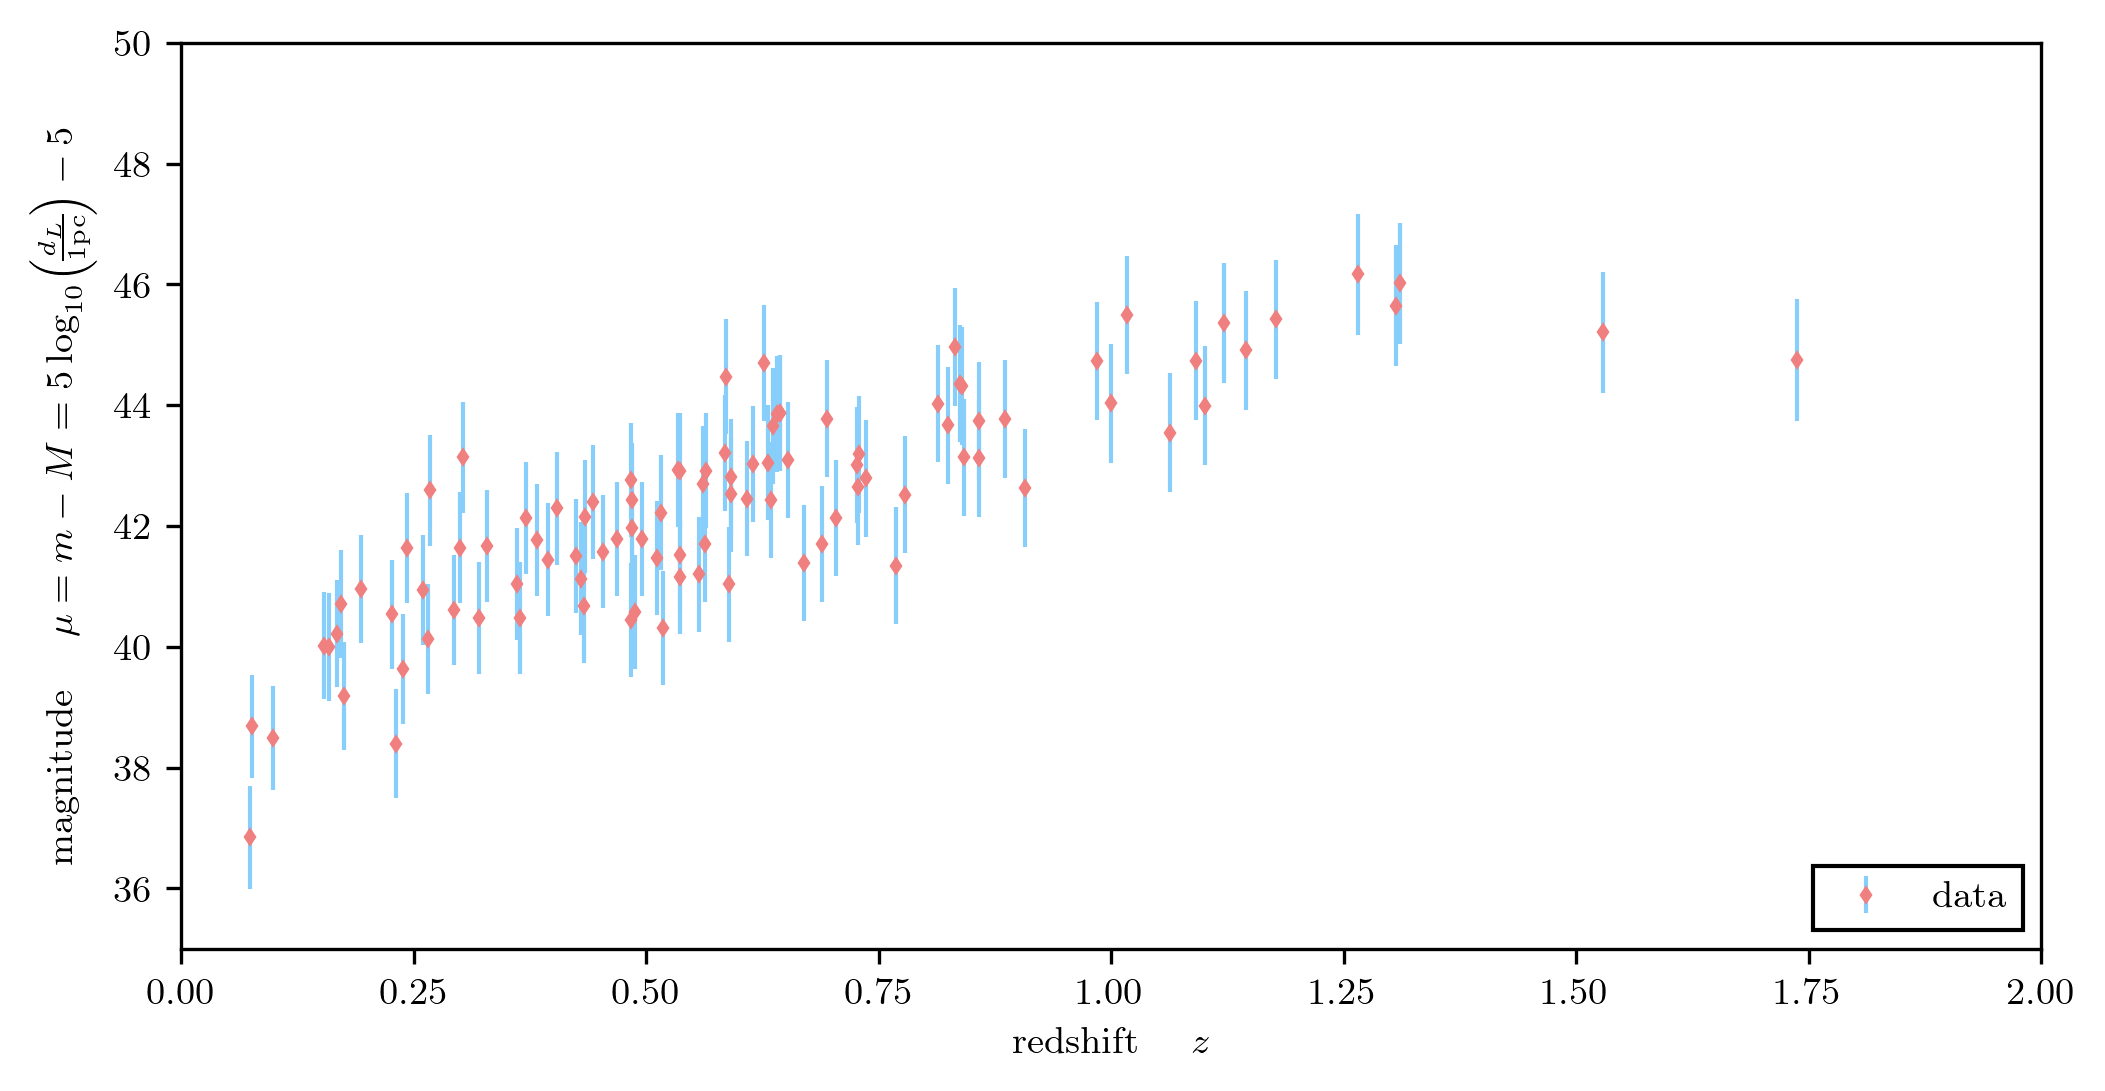

In [3]:
#-------------------------------------------------------------------------
# Generate data and visualize it
#-------------------------------------------------------------------------

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

fig , ax = plt.subplots(figsize=(8,4))

plt.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data')
plt.xlabel(r"redshift $\quad z$")
plt.ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
plt.xlim(0,2)
plt.ylim(35,50)

ax.legend(loc=4, frameon=True, framealpha=1, fancybox=False, edgecolor='black' )


#-------------------------------------------------------------------------

In [4]:
#-------------------------------------------------------------------------
# define the regressio models (polynomials of various orders)
#-------------------------------------------------------------------------

pol_degrees = range(1,11)
pol_regr = []
theta = []
mu_pred = []
for d in pol_degrees:
    pol_regr.append(PolynomialRegression(d))

In [5]:
#-------------------------------------------------------------------------
# just run a quick fit on the entire dataset for all the models
#-------------------------------------------------------------------------

z_grid = np.linspace(0,2,1000)

for i in range(10):
    pol_regr[i].fit(z_sample[:,np.newaxis], mu_sample, dmu)
    theta.append(pol_regr[i].coef_)
    mu_pred.append(pol_regr[i].predict(z_grid[:,np.newaxis]))

#-------------------------------------------------------------------------

In [6]:
#-------------------------------------------------------------------------
# just defining some color codings and labels
#-------------------------------------------------------------------------

color1ist = mcp.gen_color(cmap="magma",n=10)
# print(color1ist)

labels=[]
for i in range(10):
    l0 = r'$\mu(z) = \theta_0 + \theta_1 \, z'
    for j in range(1,i+1):
        n = '{:d}'.format(j+1) 
        l0 += r'+\theta_{' + n + '}\, z^{' + n + '}'
    l0 += '$'
    # print(l0)
    labels.append(l0)

print()

labels_nums=[]
for i in range(10):
    l0 = '$\mu(z) = {:.2f}'.format(theta[i][0])
    l0 += '+ {:.2f} \, z '.format(theta[i][1])
    for j in range(1,i+1):
        n = '{:d}'.format(j+1) 
        if theta[i][j+1]>0:
            l0 += '+{:.2f}'.format(theta[i][j+1]) + '\, z^{' + n + '}'
        else:
            l0 += '{:.2f}'.format(theta[i][j+1]) + '\, z^{' + n + '}'
    l0 += '$'
    # print(l0)
    labels_nums.append(l0)

#-------------------------------------------------------------------------

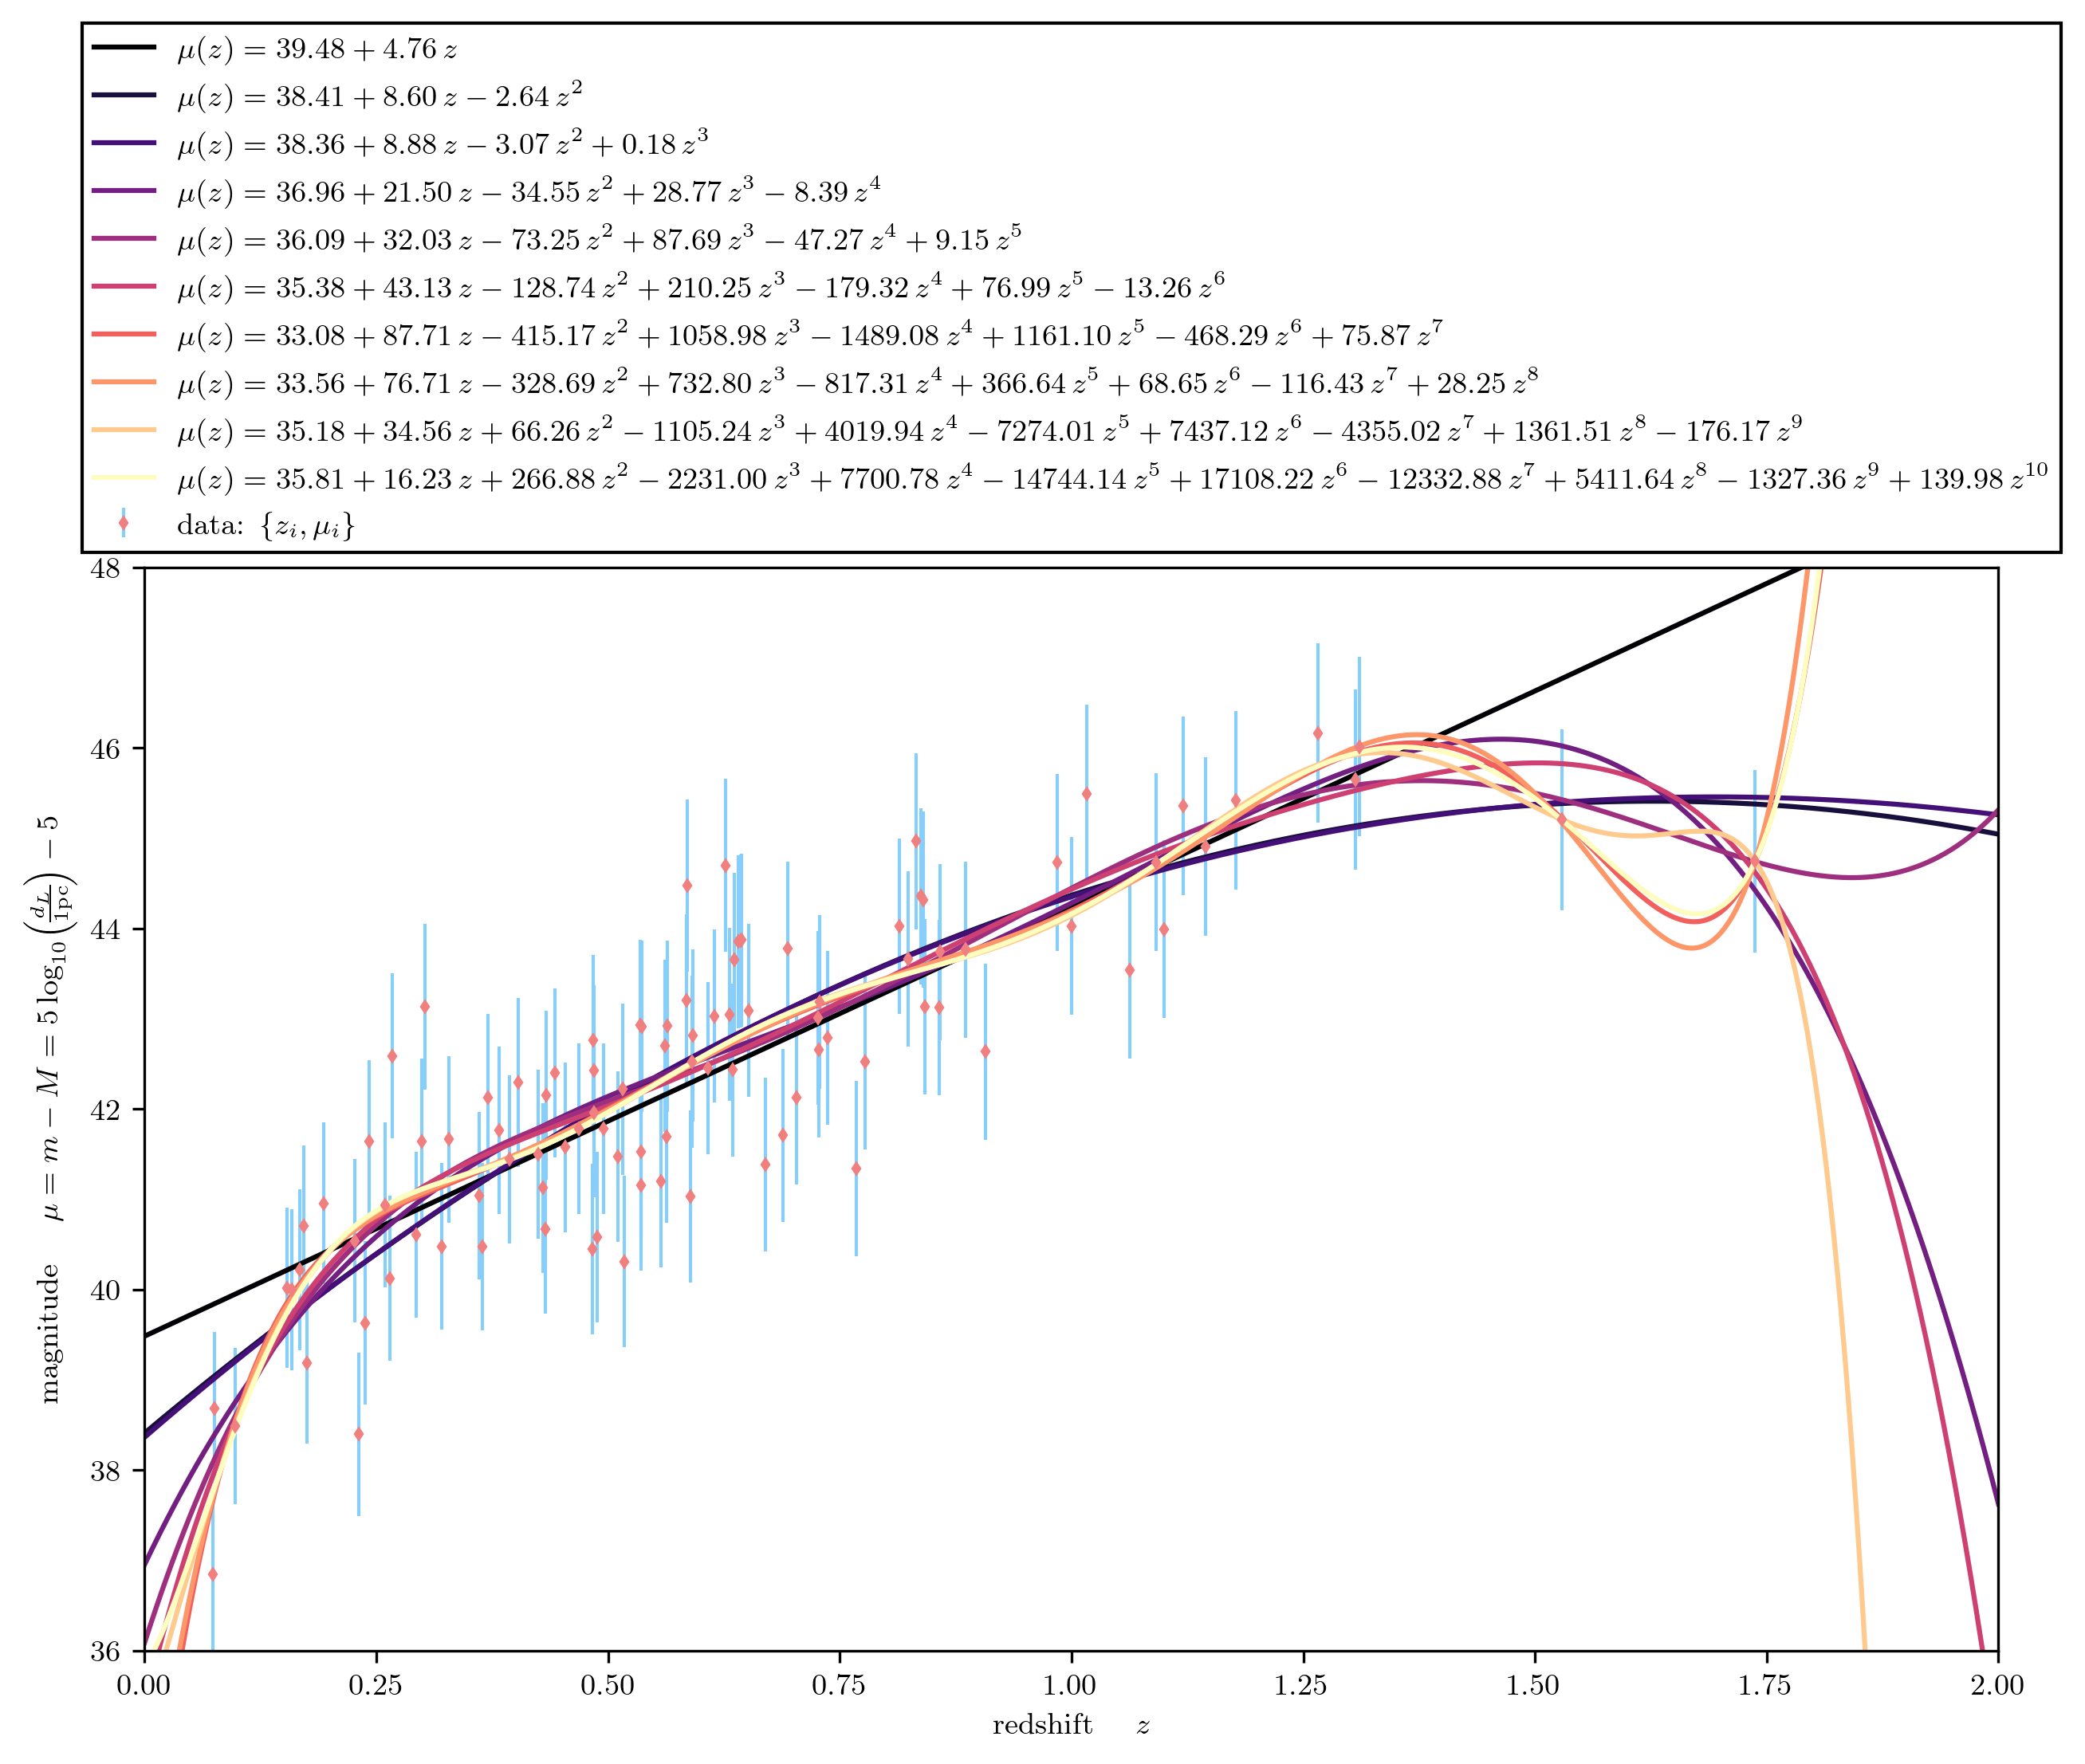

In [7]:
#-------------------------------------------------------------------------
# plot the results of the first quick fit on the entire dataset for all the models
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(10,6))

ax.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data: $\{z_i, \mu_i\}$')
ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

for i in range(10):
    ax.plot(z_grid, mu_pred[i], color=color1ist[i] , label=labels_nums[i])   #, color='khaki', alpha=1-i/(12)

_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc='lower center',bbox_to_anchor=(0.5,1.0)) #,bbox_to_anchor=(0.75,0))

if False:
    fig.savefig('./L17_images/L17__Best_Fit_Ignorant.pdf', bbox_inches='tight')
    fig.savefig('./L17_images/L17__Best_Fit_Ignorant.png', bbox_inches='tight')

#-------------------------------------------------------------------------


I guesstimate that the quadratic or cubic model have provided the best results, that I'm underfitting with the linear model, and overfitting with all other models except quadratic and cubic.

Let us now implement the cross validation.


# Quick Cross Validation to determine the best degree for the fitting polynomial

In [ ]:
#-------------------------------------------------------------------------
# split the dataset ONCE for the first Cross Validation implementation
#-------------------------------------------------------------------------

z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample, mu_sample, dmu, test_size=0.65)

#-------------------------------------------------------------------------

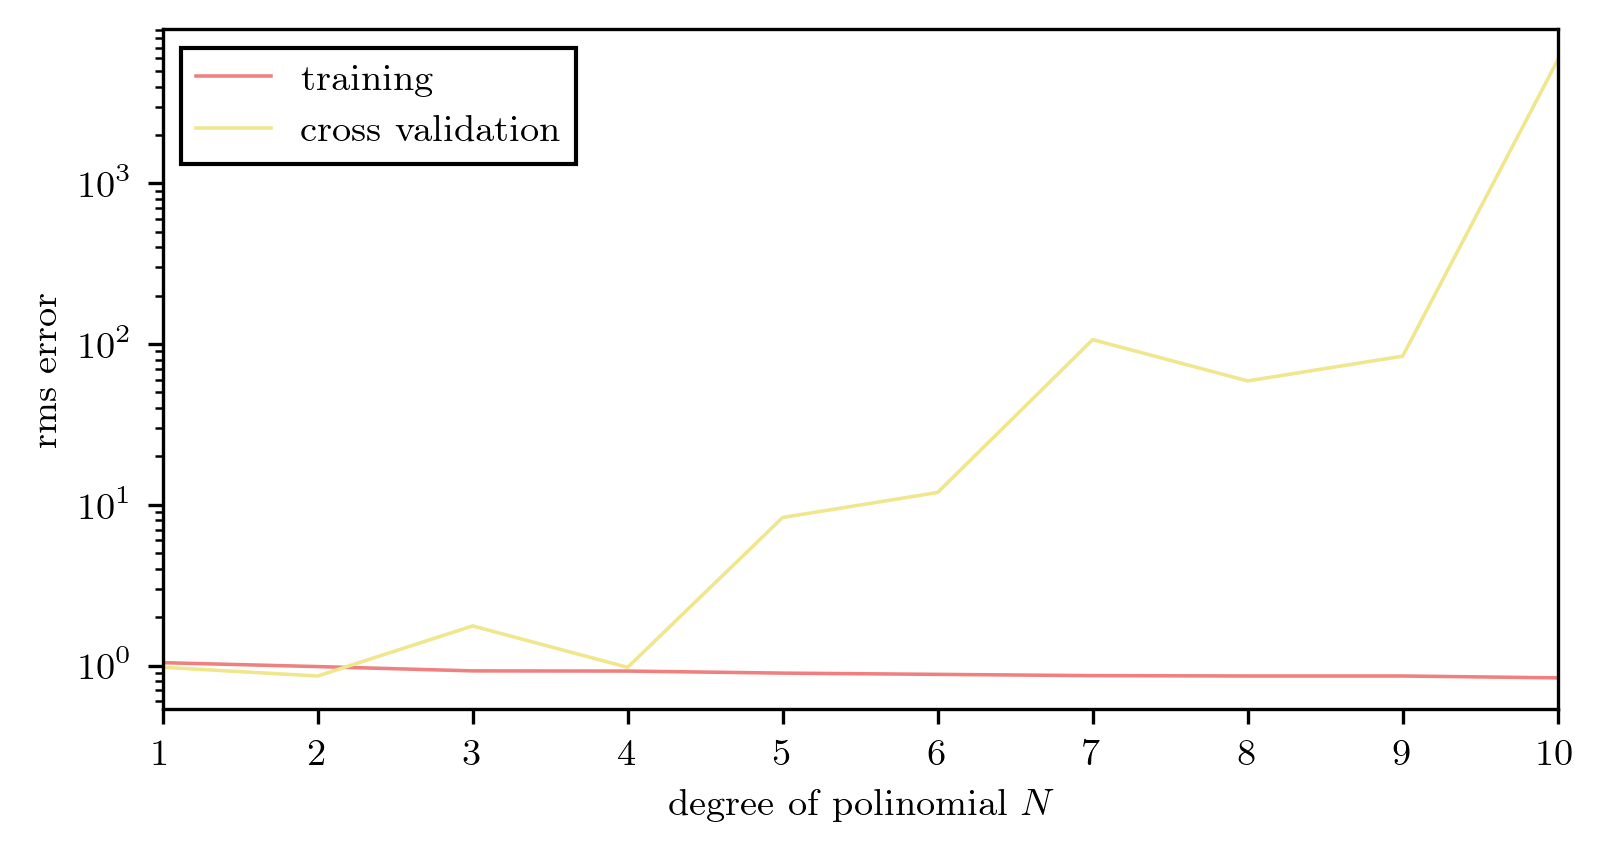

In [9]:
#-------------------------------------------------------------------------
# implement the Cross Validation routine and run it once
#-------------------------------------------------------------------------

N_train = len(z_train)
N_test  = len(z_test)

pol_degrees = range(1,11)
pol_regr = []

for d in pol_degrees:
    pol_regr.append(PolynomialRegression(d))

training_err = np.zeros(len(pol_degrees))
crossval_err = np.zeros(len(pol_degrees))

theta_train = []
mu_grid_train = []

for i in range(10):

    pol_regr[i].fit(z_train[:,np.newaxis], mu_train, dmu_train)

    theta_i = pol_regr[i].coef_
    theta_train.append(theta_i)

    mu_grid_i = pol_regr[i].predict(z_grid[:,np.newaxis])
    mu_grid_train.append(mu_grid_i)

    mu_train_i = pol_regr[i].predict(z_train[:,np.newaxis])
    mu_test_i  = pol_regr[i].predict(z_test[:,np.newaxis])

    training_err[i] = np.sqrt( np.sum( (mu_train_i - mu_train)**2 / N_train) )
    crossval_err[i] = np.sqrt( np.sum( (mu_test_i  - mu_test)**2  / N_test) )

fig , ax = plt.subplots(figsize=(6,3))

ax.plot(pol_degrees, training_err, lw=0.85, color='lightcoral', label='training')
ax.plot(pol_degrees, crossval_err, lw=0.85, color='khaki', label='cross validation')
ax.set_xlabel(r'degree of polinomial $N$')
ax.set_ylabel('rms error')
ax.set_xlim(1,10)
ax.set_yscale('log')

_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=2)

# BIC_train = np.sqrt(N_train) * training_err / dmu_train + pol_degrees * np.log(N_train)
# BIC_crossval = np.sqrt(N_train) * crossval_err / dmu_train + pol_degrees * np.log(N_train)

#-------------------------------------------------------------------------

In [ ]:
#-------------------------------------------------------------------------
# with the first Cross Validation result for the best degree of the fit polynomial
# re-do the fit on the splitted datased: train and valid
#-------------------------------------------------------------------------

best_deg = pol_degrees[np.argmin(crossval_err)]
print(best_deg)

best_pol_regr = PolynomialRegression(best_deg)

# train data only
best_pol_regr.fit(z_train[:,np.newaxis], mu_train, dmu_train)
best_theta_tr = best_pol_regr.coef_
mu_grid_tr = best_pol_regr.predict(z_grid[:,np.newaxis])

# full dataset
best_pol_regr.fit(z_sample[:,np.newaxis], mu_sample, dmu)
best_theta = best_pol_regr.coef_
mu_grid_CV = best_pol_regr.predict(z_grid[:,np.newaxis])

# 10-fold cross validation (???)
mu_pred_CV1 = cross_val_predict(best_pol_regr, z_sample[:,np.newaxis], mu_sample, cv=10)
mu_pred_CV2 = cross_val_predict(best_pol_regr, z_grid[:,np.newaxis], mu_grid_CV, cv=10)

print(best_theta)



2
[38.41076899  8.59831905 -2.64090751]


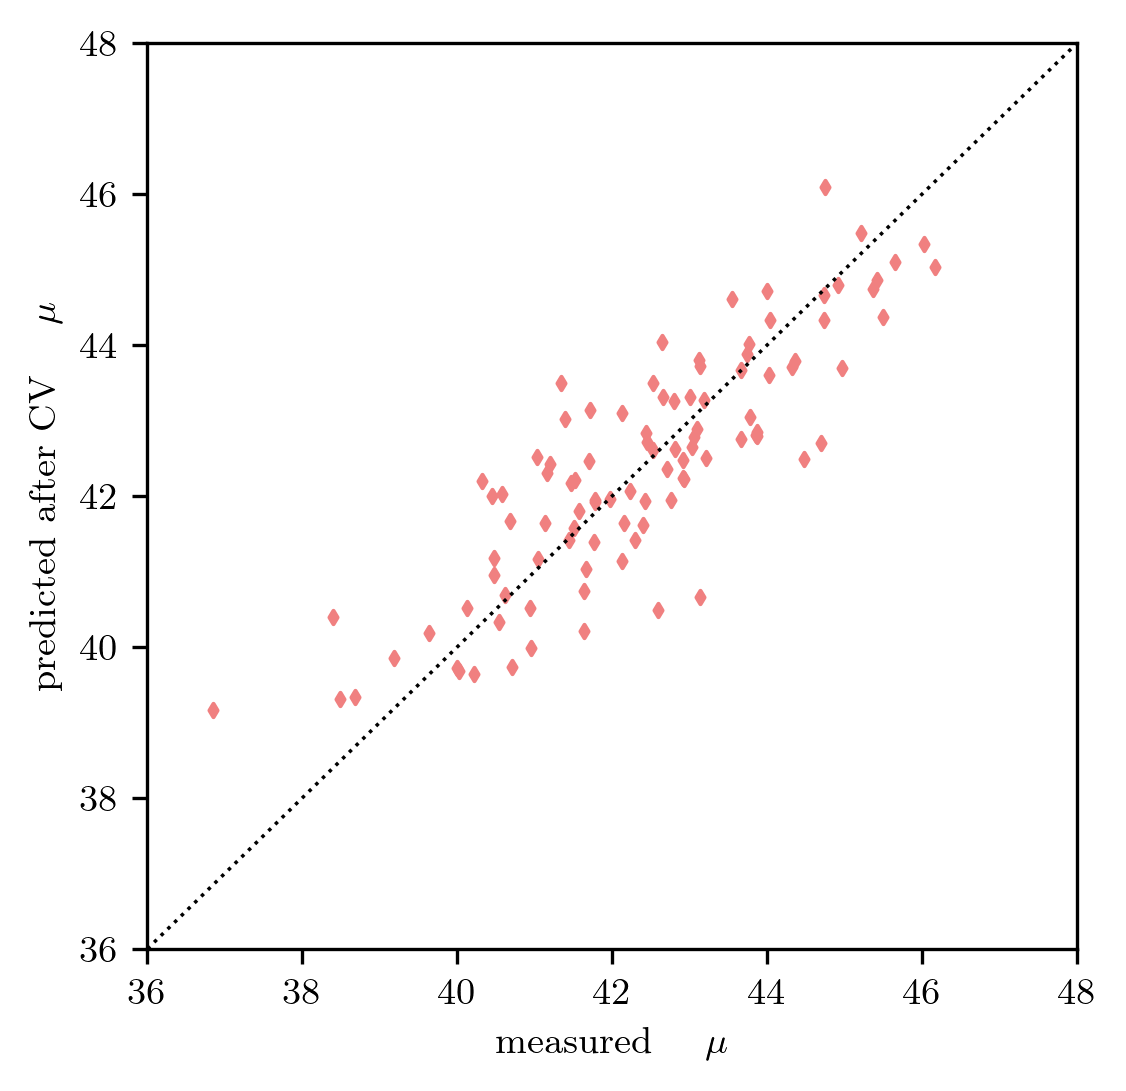

In [12]:
fig , ax = plt.subplots(figsize=(4,4))

ax.scatter(mu_sample, mu_pred_CV1, color='lightcoral', marker='d', s=5)

ax.set_xlabel(r"measured $\quad \mu$")
ax.set_ylabel(r"predicted after CV $\quad \mu $")
ax.set_xlim(36,48)
ax.set_ylim(36,48)
ax.plot(np.linspace(36,48,100),np.linspace(36,48,100), color='black', ls=':',lw=0.85)


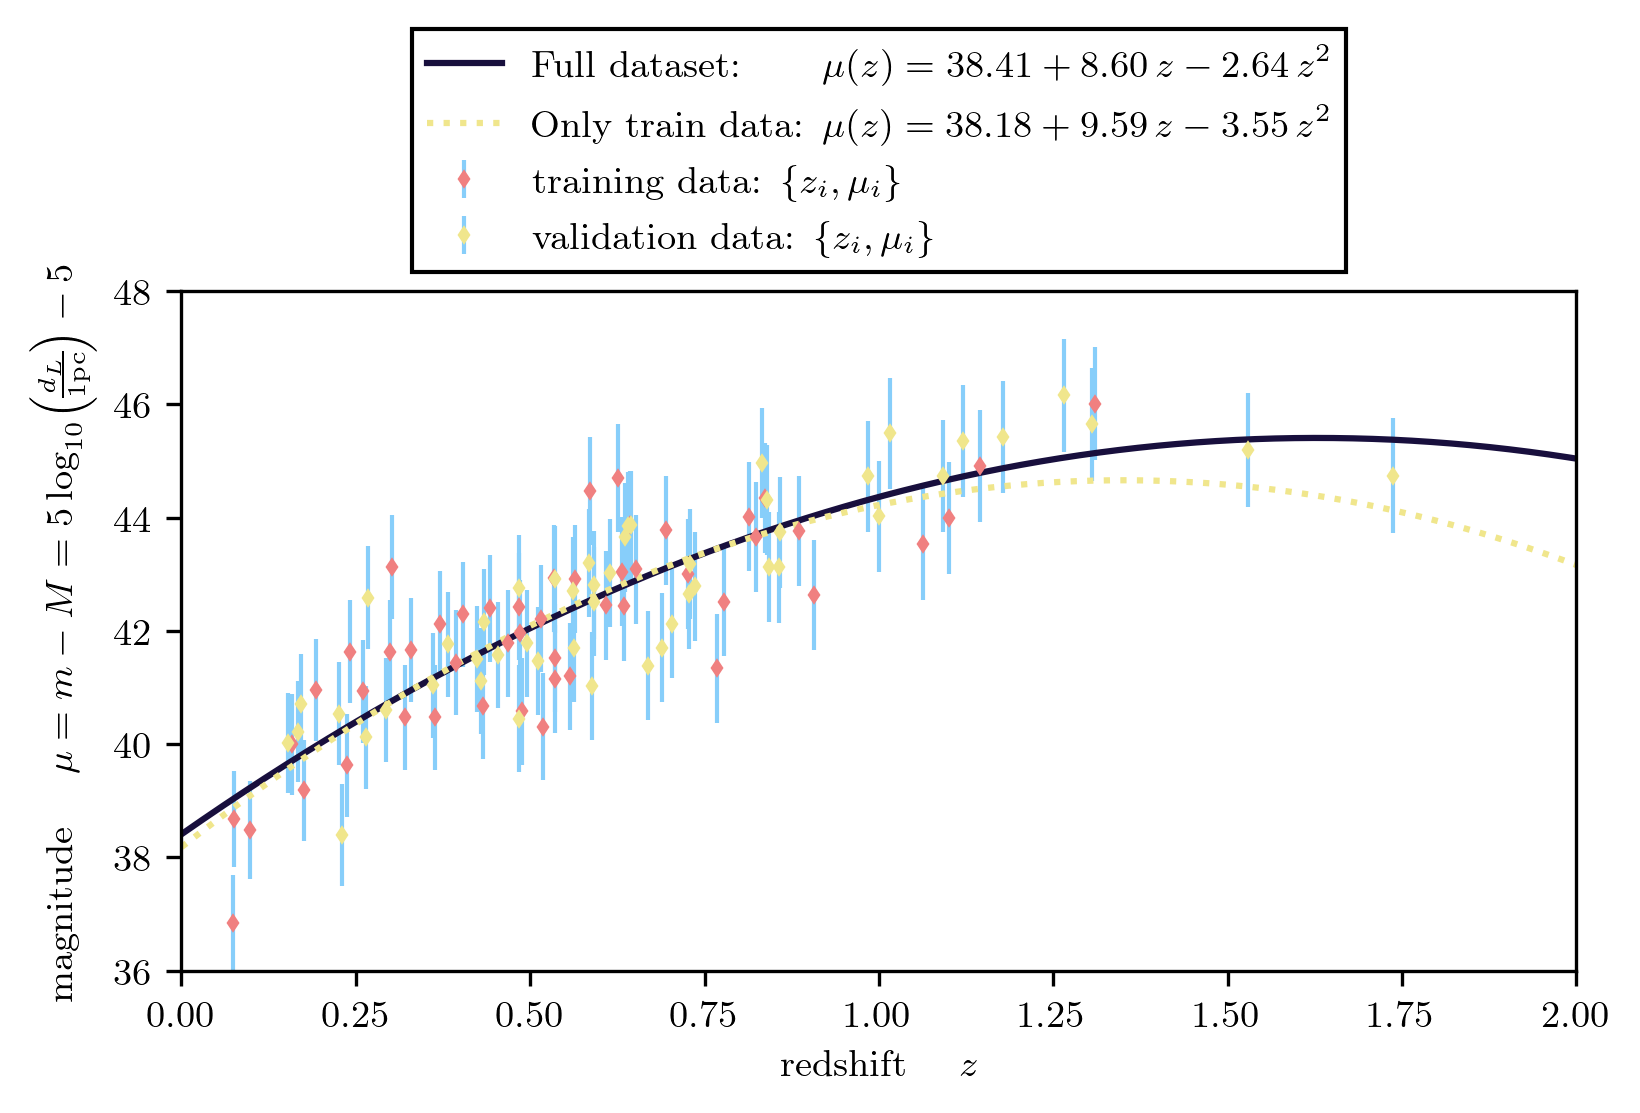

In [13]:
#-------------------------------------------------------------------------
# plot the fitting curve for training and full dataset after the first
# cross validation for determining the best fit polynomial degree
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(6,3))

# ax.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data: $\{z_i, \mu_i\}$')

ax.errorbar(z_train, mu_train, dmu_train, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='training data: $\{z_i, \mu_i\}$')
ax.errorbar(z_test, mu_test, dmu_test, color='khaki', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='validation data: $\{z_i, \mu_i\}$')


ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

best_label = 'Full dataset: $\quad\;\;\;\!\mu(z) = {:.2f}'.format(best_theta[0])
best_label += '+ {:.2f} \, z '.format(best_theta[1])
for i in range(1,best_deg):
    n = '{:d}'.format(i+1) 
    if best_theta[i+1]>0:
        best_label += '+{:.2f}'.format(best_theta[i+1]) + '\, z^{' + n + '}'
    else:
        best_label += '{:.2f}'.format(best_theta[i+1]) + '\, z^{' + n + '}'
best_label += '$'
ax.plot(z_grid, mu_grid_CV, color=color1ist[best_deg-1], label=best_label)   #, color='khaki', alpha=1-i/(12)

best_label = 'Only train data: $\mu(z) = {:.2f}'.format(best_theta_tr[0])
best_label += '+ {:.2f} \, z '.format(best_theta_tr[1])
for i in range(1,best_deg):
    n = '{:d}'.format(i+1) 
    if best_theta_tr[i+1]>0:
        best_label += '+{:.2f}'.format(best_theta_tr[i+1]) + '\, z^{' + n + '}'
    else:
        best_label += '{:.2f}'.format(best_theta_tr[i+1]) + '\, z^{' + n + '}'
best_label += '$'
ax.plot(z_grid, mu_grid_tr, color='khaki', label=best_label, ls=':')   #, color='khaki', alpha=1-i/(12)

# ax.scatter(z_sample, mu_pred_CV, c=color1ist[best_deg-1], marker='d', s=5) 


_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc='lower center',bbox_to_anchor=(0.5,1.0)) #,bbox_to_anchor=(0.75,0))

#-------------------------------------------------------------------------

# Investigate optimal training size with learning curve


In [58]:
np.linspace(0.1,0.9,17)

array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
       0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 ])

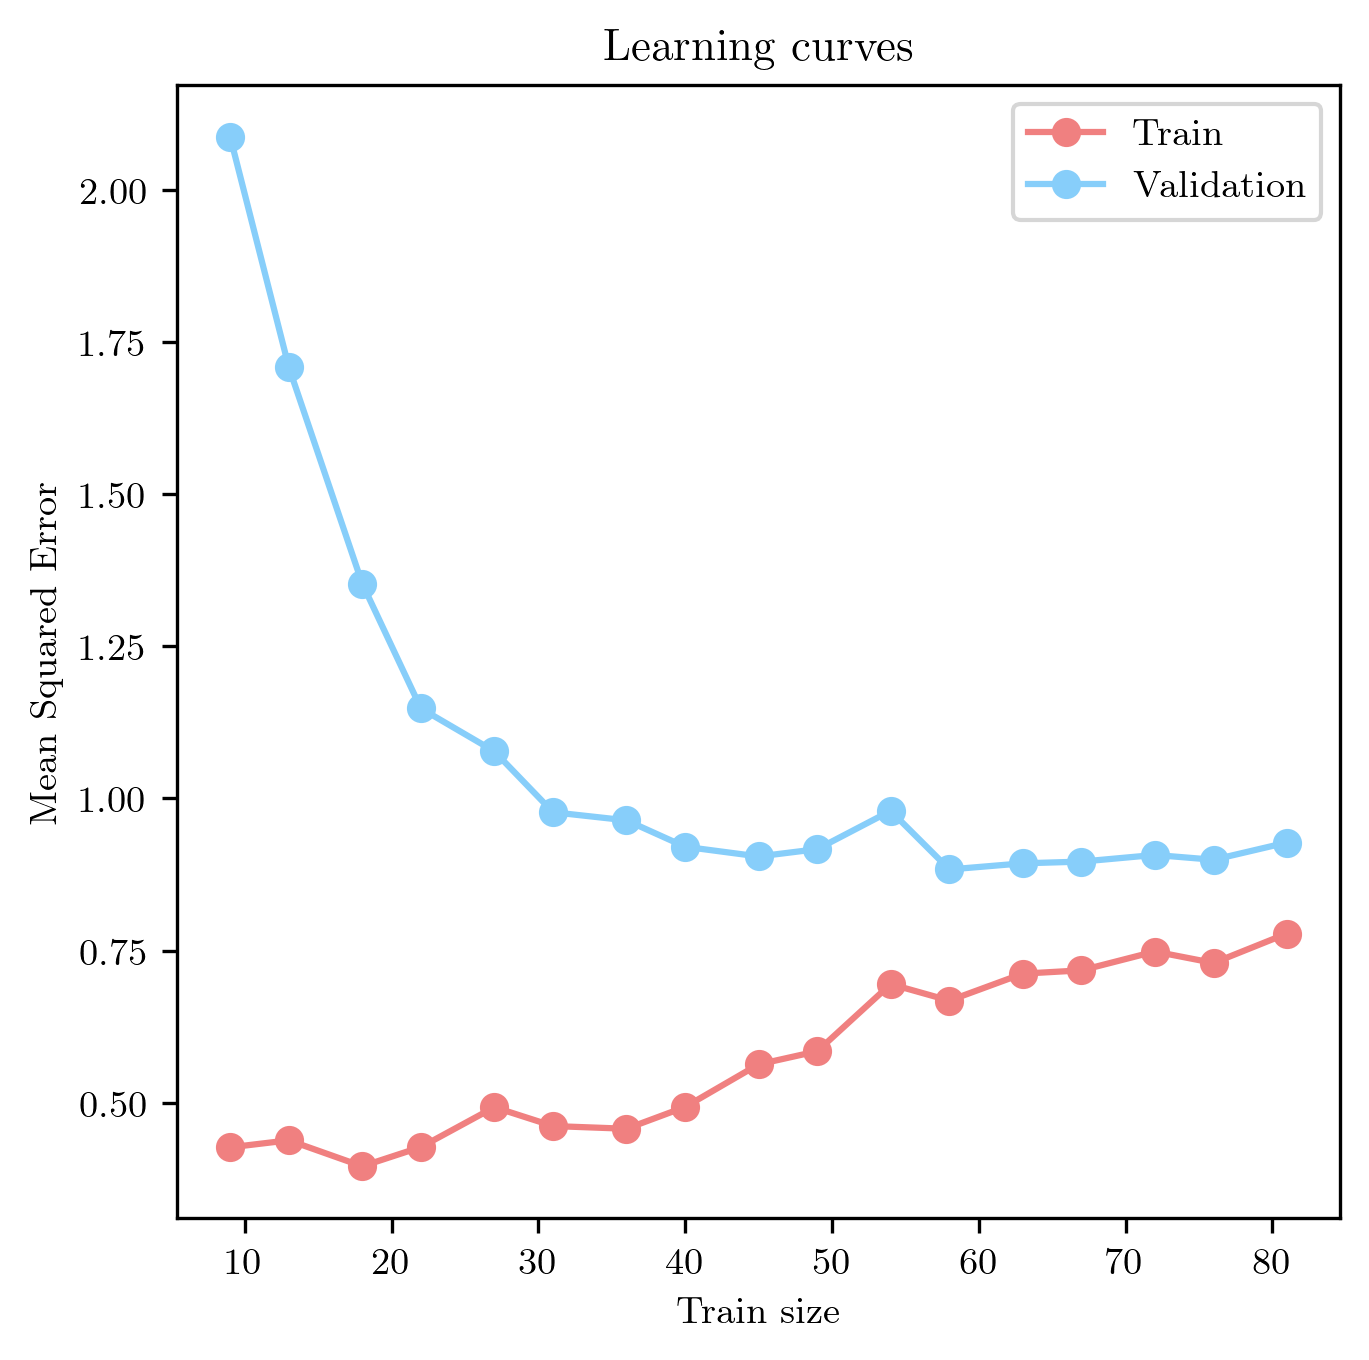

In [60]:

train_sizes, train_scores_linreg, test_scores_linreg = learning_curve(
    PolynomialRegression(best_deg), 
    z_sample[:,np.newaxis], 
    mu_sample, 
    train_sizes = np.linspace(0.1,0.9,17), 
    scoring = "neg_mean_squared_error", 
    cv = 10
)

fig , ax = plt.subplots(figsize=(5, 5))

ax.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="lightcoral", label="Train")
ax.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="lightskyblue", label="Validation")               
ax.set_xlabel("Train size")
ax.set_ylabel("Mean Squared Error")
ax.set_title('Learning curves')
ax.legend(loc="best")

Then, it looks like that an optimal test size is between 60 and 70 (the full dataset is 100). 

# More consistent Cross Validation for the best degree of the fitting polynomial, regression and visualization of the best fit results

[2, 7, 7, 2, 5, 4, 5, 8, 2, 4, 1, 4, 5, 5, 4, 5, 5, 4, 1, 1, 4, 5, 7, 7, 2, 7, 1, 4, 1, 4, 2, 4, 2, 4, 4, 2, 2, 2, 7, 4, 2, 4, 4, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 7, 2, 2, 2, 7, 4, 4, 2, 2, 2, 2, 5, 5, 4, 2, 2, 2, 2, 2, 4, 2, 2, 1, 2, 7, 4, 4, 6, 2, 7, 3, 5, 4, 5, 5, 4, 8, 7, 7, 5, 5, 2, 4, 5, 5]


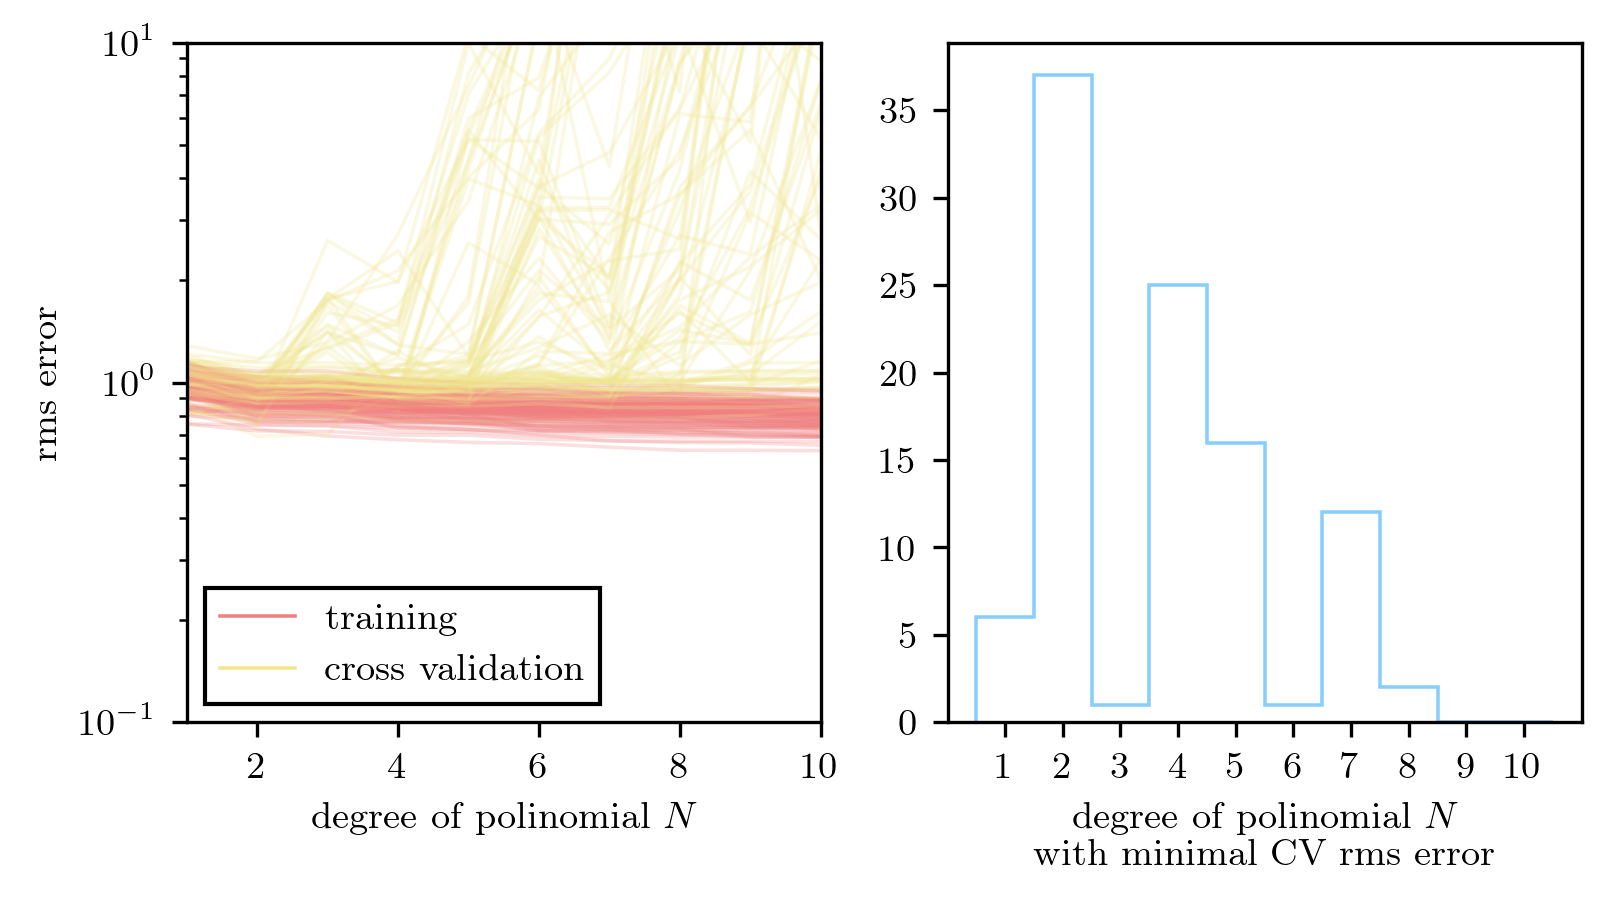

In [ ]:
#-------------------------------------------------------------------------
# Now do the Cross Validation 100 times to compute the best polynomial degree
# as the mode (most recurring result) and for this mode, average the best fits
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,2,figsize=(6,3))

ax[0].set_xlabel(r'degree of polinomial $N$')
ax[0].set_ylabel('rms error')
ax[0].set_xlim(1,10)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-1,1e1)

ax[1].set_xticks(np.linspace(1,10,10))
ax[1].set_xlabel(r'degree of polinomial $N$'+'\nwith minimal CV rms error')

best_deg_CV_lots = []
best_theta_CV_lots = []
mu_grid_lots = []

ax[0].plot([], [], lw=0.85, color='lightcoral', label='training')
ax[0].plot([], [], lw=0.85, color='khaki', label='cross validation')

for j in range(100):

    z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample, mu_sample, dmu, test_size=0.65)

    N_train = len(z_train)
    N_test  = len(z_test)

    pol_degrees = range(1,11)
    pol_regr = []

    for d in pol_degrees:
        pol_regr.append(PolynomialRegression(d))

    training_err = np.zeros(len(pol_degrees))
    crossval_err = np.zeros(len(pol_degrees))

    theta_train = []
    mu_grid_train = []

    for i in range(10):

        pol_regr[i].fit(z_train[:,np.newaxis], mu_train, dmu_train)

        theta_i = pol_regr[i].coef_
        theta_train.append(theta_i)

        mu_grid_i = pol_regr[i].predict(z_grid[:,np.newaxis])
        mu_grid_train.append(mu_grid_i)

        mu_train_i = pol_regr[i].predict(z_train[:,np.newaxis])
        mu_test_i  = pol_regr[i].predict(z_test[:,np.newaxis])

        training_err[i] = np.sqrt( np.sum( (mu_train_i - mu_train)**2 / N_train) )
        crossval_err[i] = np.sqrt( np.sum( (mu_test_i  - mu_test)**2  / N_test) )
    
    ax[0].plot(pol_degrees, training_err, alpha=0.25, lw=0.85, color='lightcoral')
    ax[0].plot(pol_degrees, crossval_err, alpha=0.25, lw=0.85, color='khaki')

    best_deg = pol_degrees[np.argmin(crossval_err)]
    best_deg_CV_lots.append(best_deg)

    best_pol_regr = PolynomialRegression(best_deg)

    # train data only
    best_pol_regr.fit(z_train[:,np.newaxis], mu_train, dmu_train)

    best_theta_tr = best_pol_regr.coef_
    best_theta_CV_lots.append(best_theta_tr)
    
    mu_grid_tr = best_pol_regr.predict(z_grid[:,np.newaxis])
    mu_grid_lots.append(mu_grid_tr)

_ = fancyhist(best_deg_CV_lots, ax=ax[1], bins=np.linspace(0.5,10.5,11), histtype='step', density=False, color='lightskyblue', lw=0.85)

_ = ax[0].legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=3)

print(best_deg_CV_lots)

best_deg_CV = stats.mode(best_deg_CV_lots).mode[0]     # weird syntax but ok

if False:
    fig.savefig('./L17_images/L17__PolynomRegr__CrossValidation.pdf', bbox_inches='tight')
    fig.savefig('./L17_images/L17__PolynomRegr__CrossValidation.png', bbox_inches='tight')

#-------------------------------------------------------------------------

_ = ''' = 
# full dataset
best_pol_regr.fit(z_sample[:,np.newaxis], mu_sample, dmu)
best_theta_tr = best_pol_regr.coef_
mu_grid_CV = best_pol_regr.predict(z_grid[:,np.newaxis])
'''

In [15]:
#-------------------------------------------------------------------------
# Organize results from multiple cross validations

print('The best degree for polynomial fitting is {:d}'.format(best_deg_CV))

best_deg_CV_lots = np.array(best_deg_CV_lots)
print(best_deg_CV_lots.shape)

best_theta_CV_lots = np.array(best_theta_CV_lots)
print(best_theta_CV_lots.shape)

mu_grid_lots = np.array(mu_grid_lots)
print(mu_grid_lots.shape)

#-------------------------------------------------------------------------
# select only the training-validation splits with N_polynomial_best=2

index = best_deg_CV_lots == best_deg_CV
# print(index)

N_best_degs = len(best_deg_CV_lots[index])
print('The number of fits we have done with {:d} is {:d}'.format(best_deg_CV, N_best_degs))

mu_grid_onlybest = np.copy(mu_grid_lots[index,:])
print(mu_grid_onlybest.shape)

mu_grid_onlybest_avg = np.average(mu_grid_onlybest, axis=0)
print(mu_grid_onlybest_avg.shape)

best_theta_onlybest = np.array(best_theta_CV_lots[index])
best_theta_onlybest_avg = np.average(best_theta_onlybest)

#-------------------------------------------------------------------------


The best degree for polynomial fitting is 2
(100,)
(100,)
(100, 1000)
The number of fits we have done with 2 is 37
(37, 1000)
(1000,)


C:\Users\andre\AppData\Local\Temp\ipykernel_13208\3666412722.py:9: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  best_theta_CV_lots = np.array(best_theta_CV_lots)


In [16]:
#-------------------------------------------------------------------------
# I'm not supposed to know this but I'm not using this info, 
# just plotting it for comparison
#-------------------------------------------------------------------------

cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
mu_true = cosmo.distmod(z_grid)

#-------------------------------------------------------------------------

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\astropy\cosmology\flrw.py:1280: RuntimeWarning: divide by zero encountered in log10
  val = 5. * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


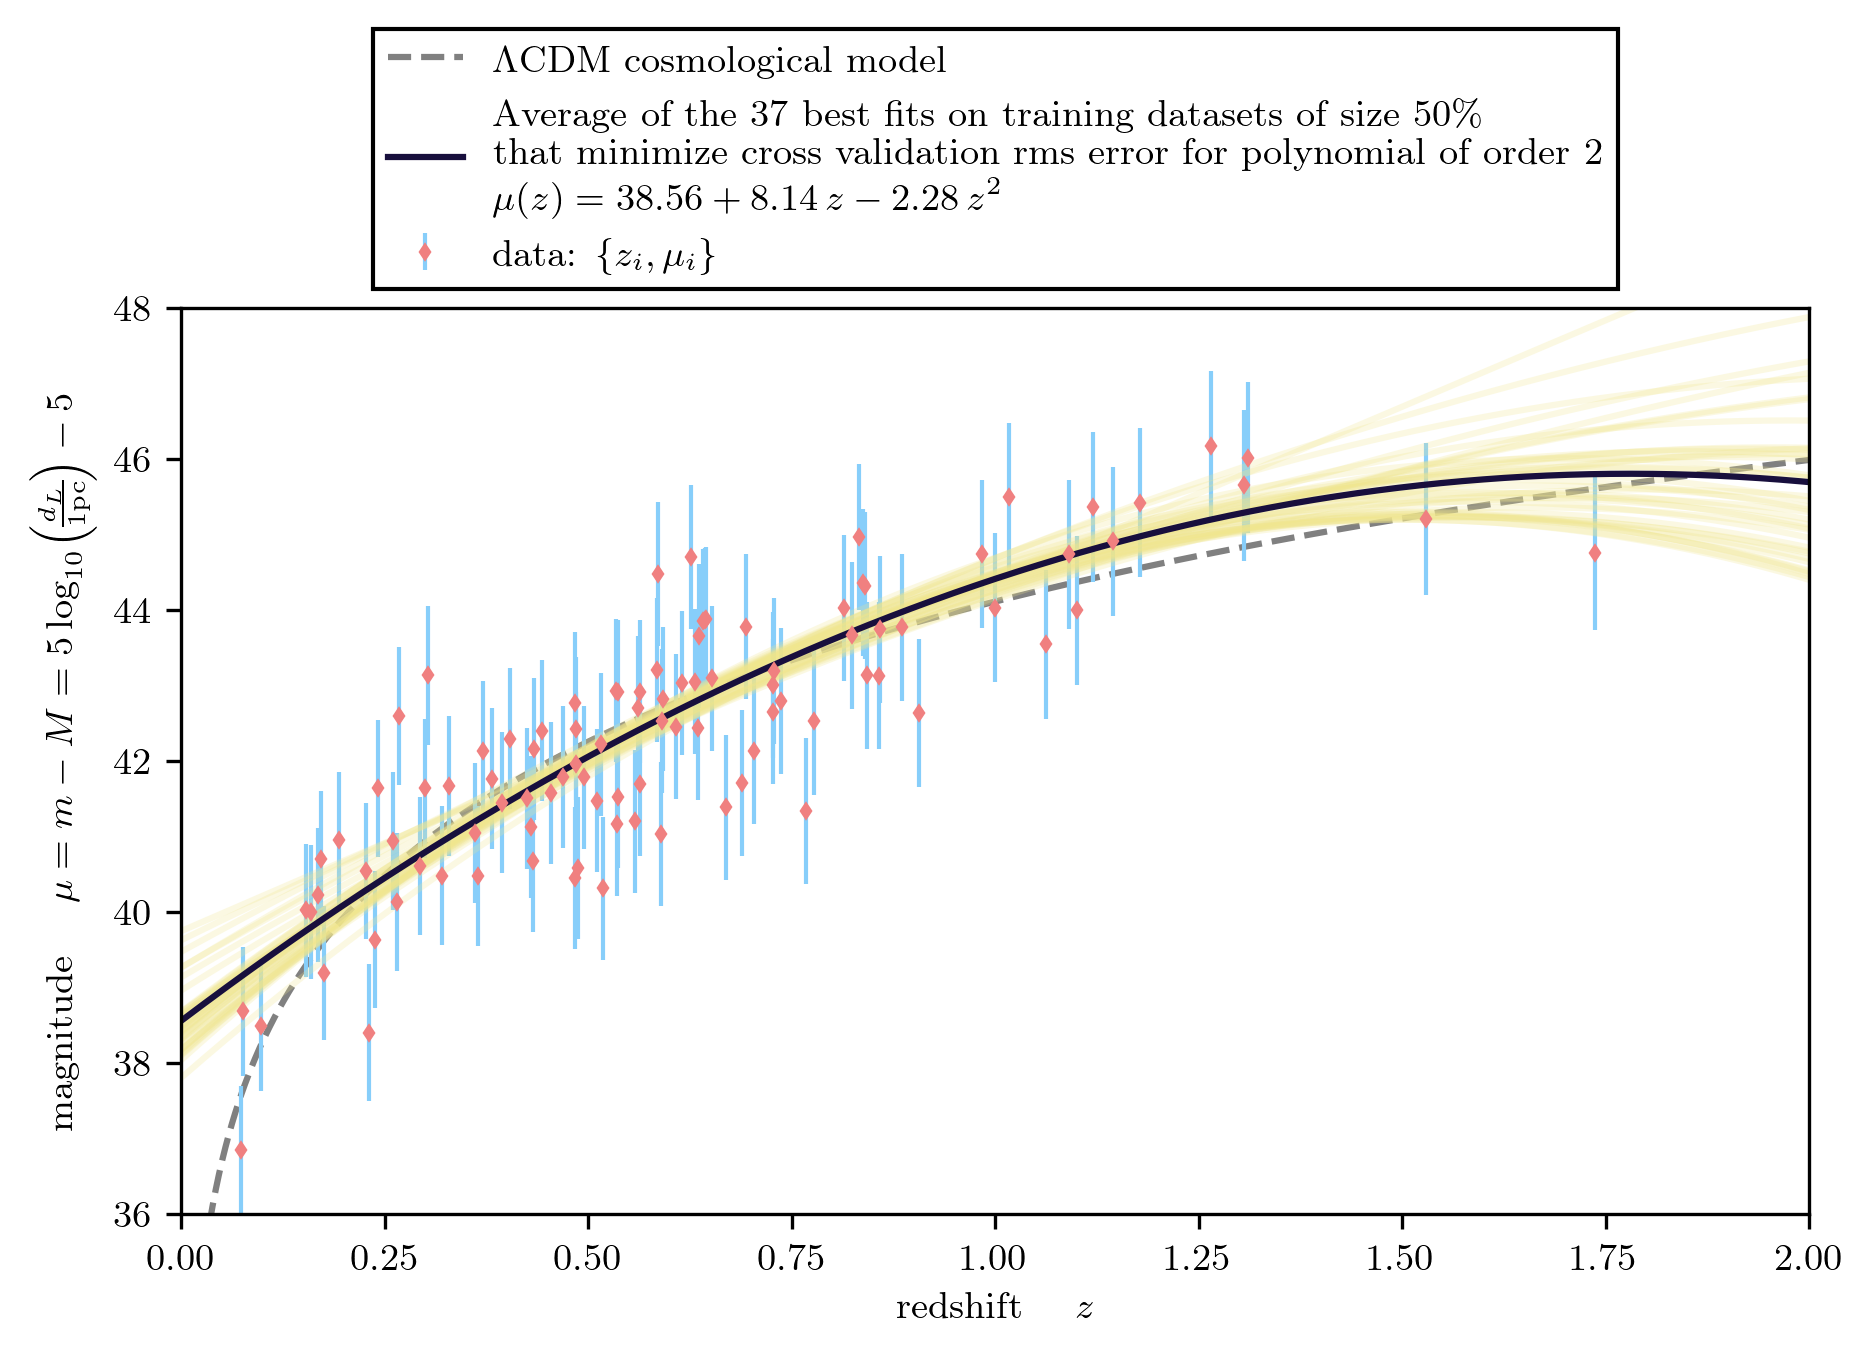

In [17]:
#-------------------------------------------------------------------------
# finally plot the best fit curve as average of the cross validated models
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(7,4))

ax.plot(z_grid, mu_true, color='gray', label='$\Lambda$CDM cosmological model', ls='--')

ax.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data: $\{z_i, \mu_i\}$')

ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

# ax.plot(z_grid, mu_grid_CV, color=color1ist[best_deg_CV-1], label=best_label)  
for i in range(N_best_degs):
    ax.plot(z_grid, mu_grid_onlybest[i,:], color='khaki', alpha=0.25) 

labellina = 'Average of the {:d} best fits on training datasets of size 50\%\n'.format(N_best_degs)
labellina += 'that minimize cross validation rms error for polynomial of order {:d}\n'.format(best_deg_CV)
labellina += '$\mu(z) = {:.2f}'.format(best_theta_onlybest_avg[0])
if best_theta_onlybest_avg[1] >= 0:
    labellina += '+ {:.2f} \, z '.format(best_theta_onlybest_avg[1])
else:
    labellina += '{:.2f} \, z '.format(best_theta_onlybest_avg[1])
if best_theta_onlybest_avg[2] >= 0:
    labellina += '+ {:.2f} \, z^2 $'.format(best_theta_onlybest_avg[2])
else: 
    labellina += '{:.2f} \, z^2 $'.format(best_theta_onlybest_avg[2])

ax.plot(z_grid, mu_grid_onlybest_avg, color=color1ist[best_deg_CV-1], label=labellina) 

mu_check = best_theta_onlybest_avg[0] + best_theta_onlybest_avg[1] * z_grid + best_theta_onlybest_avg[2] * z_grid**2
# ax.plot(z_grid, mu_grid_onlybest_avg, color='red', ls=':') 
# indeed they are the correct params for the avg line, just checking the maths

_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc='lower center',bbox_to_anchor=(0.5,1.0)) #,bbox_to_anchor=(0.75,0))


if False:
    fig.savefig('./L17_images/L17__PolynomRegr__Best_Fit_CrossValidated.pdf', bbox_inches='tight')
    fig.savefig('./L17_images/L17__PolynomRegr__Best_Fit_CrossValidated.png', bbox_inches='tight')

#-------------------------------------------------------------------------

# Repeat CV and regression for Functional (Gaussian) Basis Regression

[1, 7, 3, 1, 7, 2, 4, 6, 3, 4, 5, 7, 2, 1, 5, 5, 8, 4, 7, 2, 4, 2, 7, 3, 4, 7, 4, 1, 3, 4, 4, 7, 4, 5, 2, 4, 7, 1, 2, 3, 2, 7, 7, 1, 4, 3, 5, 3, 1, 7, 1, 1, 2, 3, 1, 3, 3, 5, 4, 3, 2, 6, 7, 3, 3, 8, 5, 5, 5, 4, 7, 2, 7, 2, 2, 7, 2, 2, 5, 2, 1, 3, 7, 2, 1, 5, 4, 5, 4, 7, 2, 2, 4, 3, 4, 3, 5, 2, 4, 3]


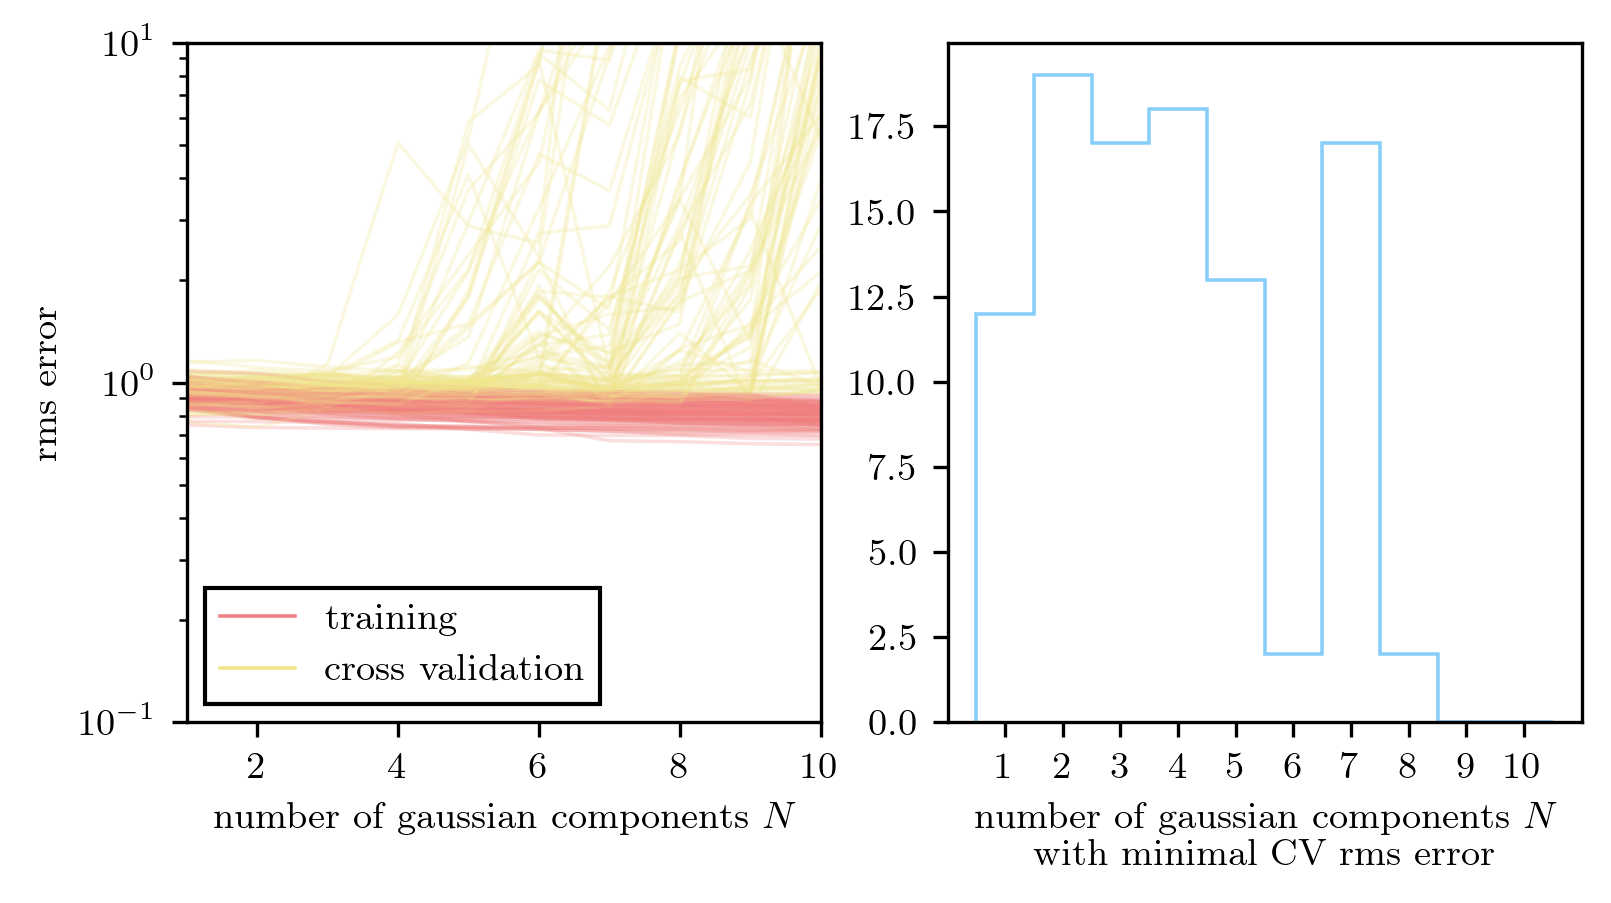

In [ ]:
#-------------------------------------------------------------------------
# Now do the Cross Validation 100 times to compute the best basis function and n_components
# as the mode (most recurring result) and for this mode, average the best fits
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,2,figsize=(6,3))

ax[0].set_xlabel(r'number of gaussian components $N$')
ax[0].set_ylabel('rms error')
ax[0].set_xlim(1,10)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-1,1e1)

ax[1].set_xticks(np.linspace(1,10,10))
ax[1].set_xlabel(r'number of gaussian components $N$'+'\nwith minimal CV rms error')

best_deg_basis_lots = []
best_theta_basis_lots = []
component_basis_lots = []
mu_grid_basis_lots = []

basis_degrees = range(1,11)

ax[0].plot([], [], lw=0.85, color='lightcoral', label='training')
ax[0].plot([], [], lw=0.85, color='khaki', label='cross validation')

for j in range(100):

    z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample, mu_sample, dmu, test_size=0.65)

    N_train = len(z_train)
    N_test  = len(z_test)

    basis_regr = []

    for d in basis_degrees:
        component_basis = np.linspace(2,0,d)    
        if d>1:
            component_basis_width = component_basis[1] - component_basis[0]
        else: 
            component_basis_width = 2
        component_basis_lots.append(component_basis)
        basis_regr.append(BasisFunctionRegression('gaussian', mu=component_basis[:,np.newaxis], sigma=component_basis_width))

    training_err = np.zeros(len(basis_degrees))
    crossval_err = np.zeros(len(basis_degrees))

    theta_train = []
    mu_grid_train = []

    for i in range(len(basis_degrees)):

        basis_regr[i].fit(z_train[:,np.newaxis], mu_train, dmu_train)

        theta_i = basis_regr[i].coef_
        theta_train.append(theta_i)

        mu_grid_i = basis_regr[i].predict(z_grid[:,np.newaxis])
        mu_grid_train.append(mu_grid_i)

        mu_train_i = basis_regr[i].predict(z_train[:,np.newaxis])
        mu_test_i  = basis_regr[i].predict(z_test[:,np.newaxis])

        training_err[i] = np.sqrt( np.sum( (mu_train_i - mu_train)**2 / N_train) )
        crossval_err[i] = np.sqrt( np.sum( (mu_test_i  - mu_test)**2  / N_test) )
    
    ax[0].plot(basis_degrees, training_err, alpha=0.25, lw=0.85, color='lightcoral')
    ax[0].plot(basis_degrees, crossval_err, alpha=0.25, lw=0.85, color='khaki')

    best_deg = basis_degrees[np.argmin(crossval_err)]
    best_deg_basis_lots.append(best_deg)

    best_component_basis = np.linspace(2,0,best_deg)  
    if best_deg>1:
        best_component_basis_width = best_component_basis[1] - best_component_basis[0]
    else: 
        best_component_basis_width = 2
    best_basis_regr = BasisFunctionRegression('gaussian', mu=best_component_basis[:,np.newaxis], sigma=best_component_basis_width)

    # train data only
    best_basis_regr.fit(z_train[:,np.newaxis], mu_train, dmu_train)

    best_theta_tr = best_basis_regr.coef_
    best_theta_basis_lots.append(best_theta_tr)
    
    mu_grid_tr = best_basis_regr.predict(z_grid[:,np.newaxis])
    mu_grid_basis_lots.append(mu_grid_tr)

_ = fancyhist(best_deg_basis_lots, ax=ax[1], bins=np.linspace(0.5,10.5,11), histtype='step', density=False, color='lightskyblue', lw=0.85)

_ = ax[0].legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=3)

print(best_deg_basis_lots)

best_deg_basis = stats.mode(best_deg_basis_lots).mode[0]     # weird syntax but ok

if False:
    fig.savefig('./L17_images/L17__BasisRegr__CrossValidation.pdf', bbox_inches='tight')
    fig.savefig('./L17_images/L17__BasisRegr__CrossValidation.png', bbox_inches='tight')

#-------------------------------------------------------------------------

In [19]:
#-------------------------------------------------------------------------
# Organize results from multiple cross validations

print('The best number of basis gaussians is {:d}'.format(best_deg_basis))

best_deg_basis_lots = np.array(best_deg_basis_lots)
print(best_deg_basis_lots.shape)

best_theta_basis_lots = np.array(best_theta_basis_lots)
print(best_theta_basis_lots.shape)

mu_grid_basis_lots = np.array(mu_grid_basis_lots)
print(mu_grid_basis_lots.shape)

#-------------------------------------------------------------------------
# select only the training-validation splits with N_polynomial_best=2

index_basis = best_deg_basis_lots == best_deg_basis
# print(index)
print(index_basis)
N_best_degs_gauss = len(best_deg_basis_lots[index_basis])
print('The number of fits we have done with {:d} gaussians is {:d}'.format(best_deg_basis, N_best_degs_gauss))

mu_grid_basis_onlybest = np.copy(mu_grid_basis_lots[index_basis,:])
print(mu_grid_basis_onlybest.shape)

mu_grid_basis_onlybest_avg = np.average(mu_grid_basis_onlybest, axis=0)
print(mu_grid_basis_onlybest_avg.shape)

best_theta_basis_onlybest = np.array(best_theta_basis_lots[index_basis])
best_theta_basis_onlybest_avg = np.average(best_theta_basis_onlybest)

#-------------------------------------------------------------------------


The best number of basis gaussians is 2
(100,)
(100,)
(100, 1000)
[False False False False False  True False False False False False False
  True False False False False False False  True False  True False False
 False False False False False False False False False False  True False
 False False  True False  True False False False False False False False
 False False False False  True False False False False False False False
  True False False False False False False False False False False  True
 False  True  True False  True  True False  True False False False  True
 False False False False False False  True  True False False False False
 False  True False False]
The number of fits we have done with 2 gaussians is 19
(19, 1000)
(1000,)


C:\Users\andre\AppData\Local\Temp\ipykernel_13208\3875546937.py:9: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  best_theta_basis_lots = np.array(best_theta_basis_lots)


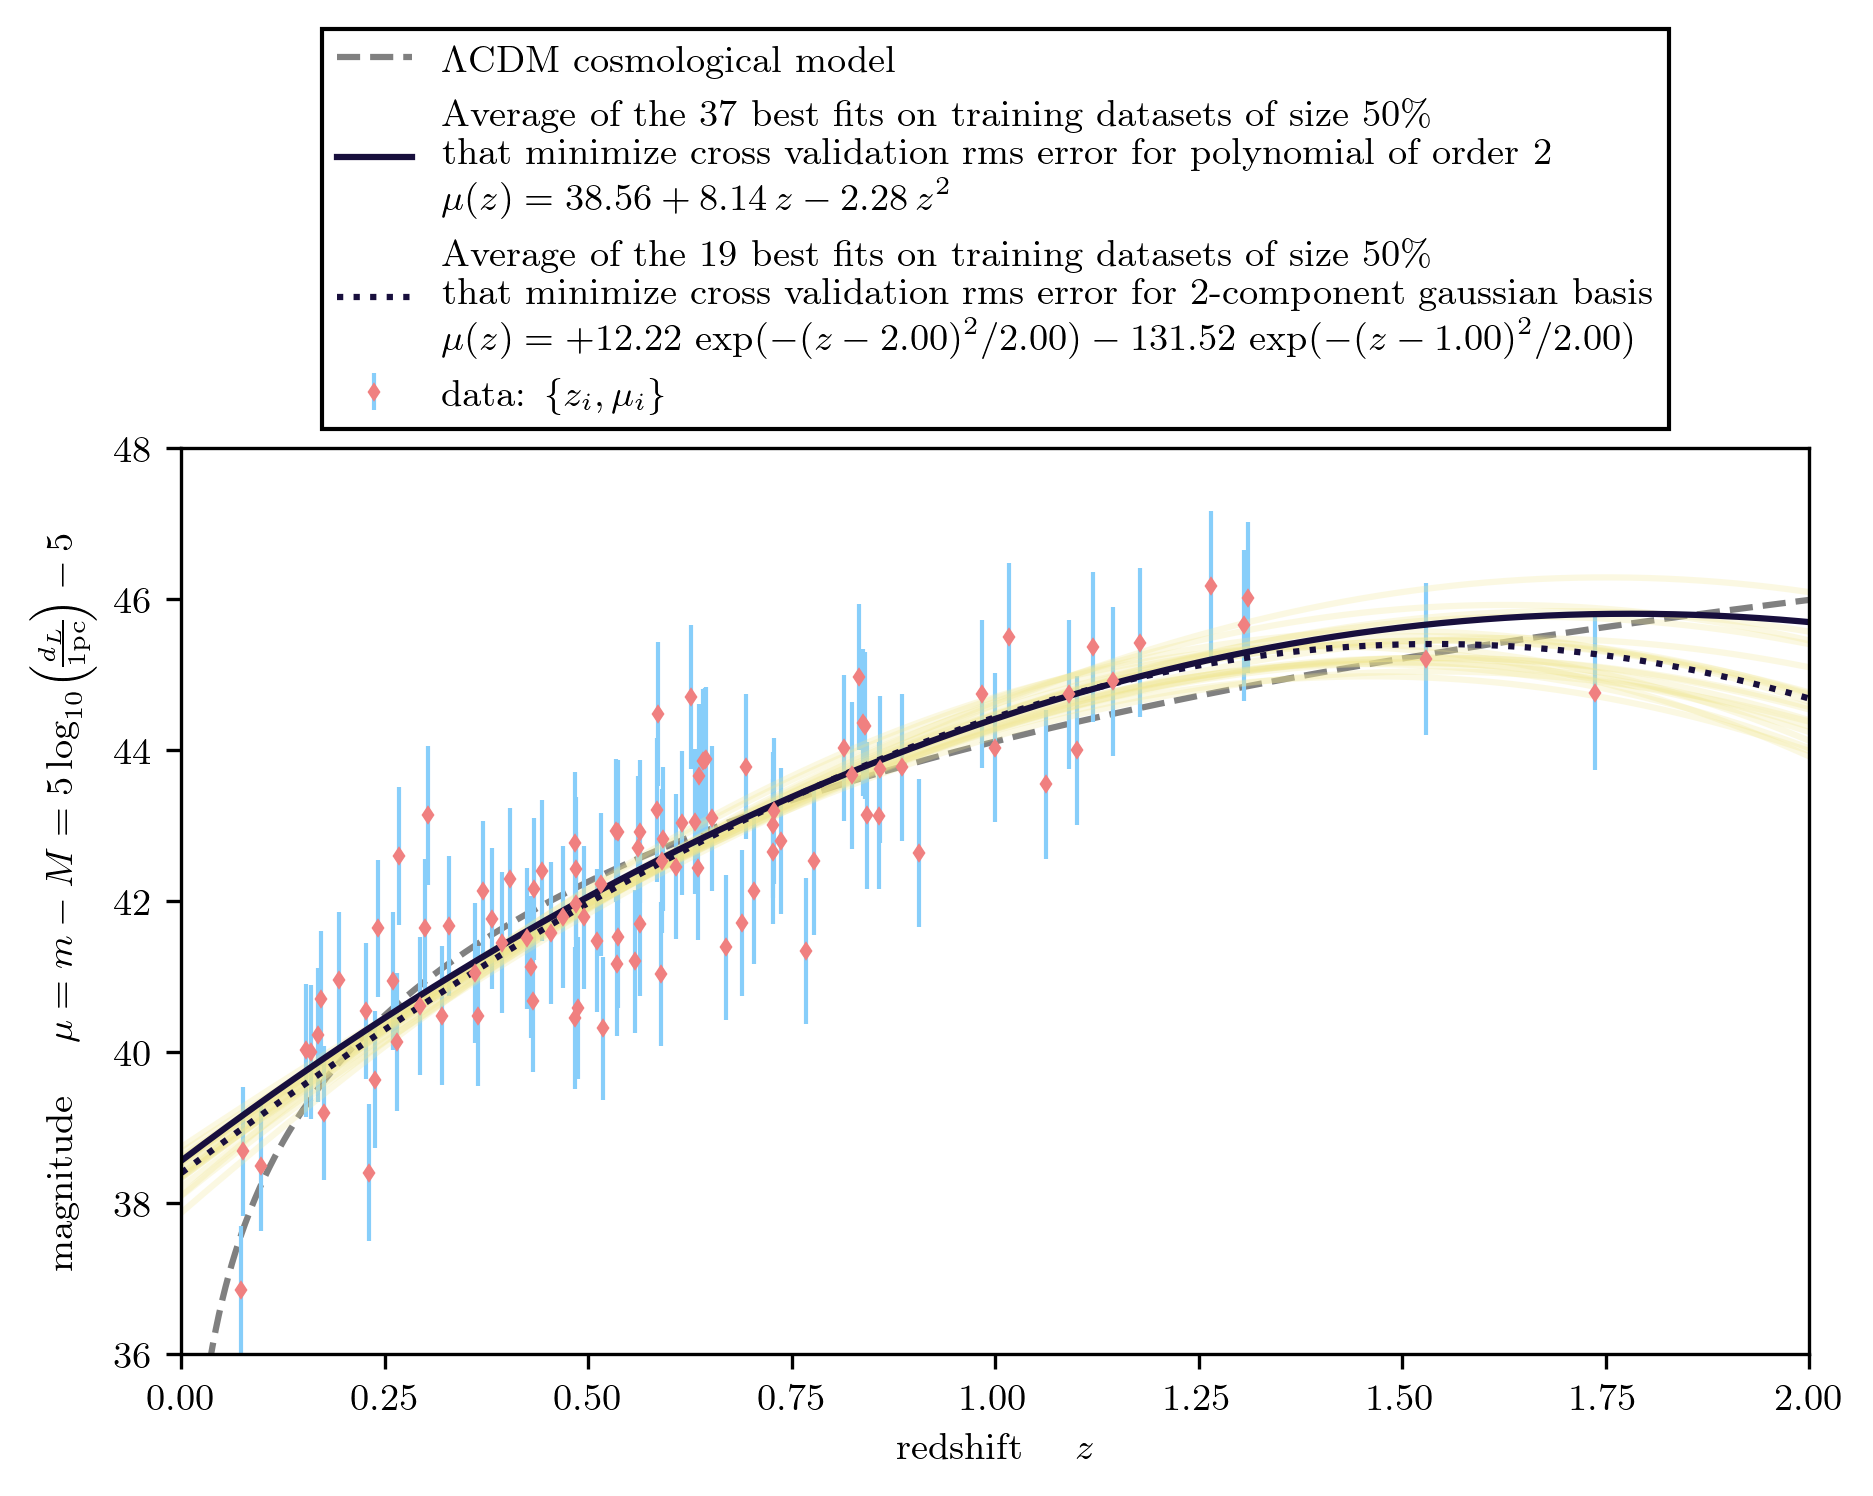

In [ ]:
#-------------------------------------------------------------------------
# finally plot the best fit curve as average of the cross validated models
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(7,4))

ax.plot(z_grid, mu_true, color='gray', label='$\Lambda$CDM cosmological model', ls='--')

ax.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data: $\{z_i, \mu_i\}$')

ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

# ax.plot(z_grid, mu_grid_basis, color=color1ist[best_deg_basis-1], label=best_label)  
for i in range(N_best_degs_gauss):
    ax.plot(z_grid, mu_grid_basis_onlybest[i,:], color='khaki', alpha=0.25) 

ax.plot(z_grid, mu_grid_onlybest_avg, color=color1ist[best_deg_CV-1], label=labellina) 

labellina_basis = 'Average of the {:d} best fits on training datasets of size 50\%\n'.format(N_best_degs_gauss)
labellina_basis += 'that minimize cross validation rms error for {:d}-component gaussian basis\n'.format(best_deg_basis)
labellina_basis += '$\mu(z) = '
for j in range(0,best_deg_basis):
    if best_theta_basis_onlybest_avg[j] >= 0:
        labellina_basis += '+ {:.2f} \, \exp(-(z-'.format(best_theta_basis_onlybest_avg[j]) 
        labellina_basis += '{:.2f})^2 / {:.2f})'.format(best_component_basis[j], 2*best_component_basis_width**2)
    else:
        labellina_basis += '{:.2f} \, \exp(-(z-'.format(best_theta_basis_onlybest_avg[j]) 
        labellina_basis += '{:.2f})^2 / {:.2f})'.format(best_component_basis[j], 2*best_component_basis_width**2)
labellina_basis += '$'

ax.plot(z_grid, mu_grid_basis_onlybest_avg, color=color1ist[best_deg_basis-1], ls=':', label=labellina_basis) 


_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc='lower center',bbox_to_anchor=(0.5,1.0)) #,bbox_to_anchor=(0.75,0))


if False:
    fig.savefig('./L17_images/L17__BasisRegr__Best_Fit_CrossValidated.pdf', bbox_inches='tight')
    fig.savefig('./L17_images/L17__BasisRegr__Best_Fit_CrossValidated.png', bbox_inches='tight')

#-------------------------------------------------------------------------

# Repeat CV and regression for Nadaraya-Watson Kernel Regression

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\astroML\linear_model\kernel_regression.py:52: RuntimeWarning: invalid value encountered in true_divide
  return (K * self.y).sum(1) / K.sum(1)
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\astroML\linear_model\kernel_regression.py:52: RuntimeWarning: invalid value encountered in true_divide
  return (K * self.y).sum(1) / K.sum(1)
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\astroML\linear_model\kernel_regression.py:52: RuntimeWarning: invalid value encountered in true_divide
  return (K * self.y).sum(1) / K.sum(1)
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\astroML\linear_model\ke

[0.026, 0.082, 0.031, 0.213, 0.046, 0.026, 0.026, 0.046, 0.172, 0.036, 0.147, 0.051, 0.102, 0.031, 0.036, 0.031, 0.046, 0.051, 0.031, 0.117, 0.041, 0.056, 0.077, 0.026, 0.031, 0.036, 0.031, 0.046, 0.041, 0.021, 0.031, 0.031, 0.051, 0.036, 0.092, 0.061, 0.067, 0.122, 0.061, 0.061, 0.061, 0.107, 0.036, 0.051, 0.061, 0.031, 0.061, 0.031, 0.036, 0.036, 0.046, 0.031, 0.107, 0.127, 0.036, 0.041, 0.051, 0.152, 0.031, 0.046, 0.026, 0.162, 0.031, 0.051, 0.036, 0.051, 0.077, 0.056, 0.067, 0.041, 0.031, 0.041, 0.026, 0.077, 0.087, 0.036, 0.082, 0.112, 0.031, 0.056, 0.041, 0.046, 0.026, 0.112, 0.061, 0.067, 0.046, 0.041, 0.208, 0.056, 0.036, 0.021, 0.036, 0.132, 0.077, 0.056, 0.056, 0.016, 0.046, 0.026]


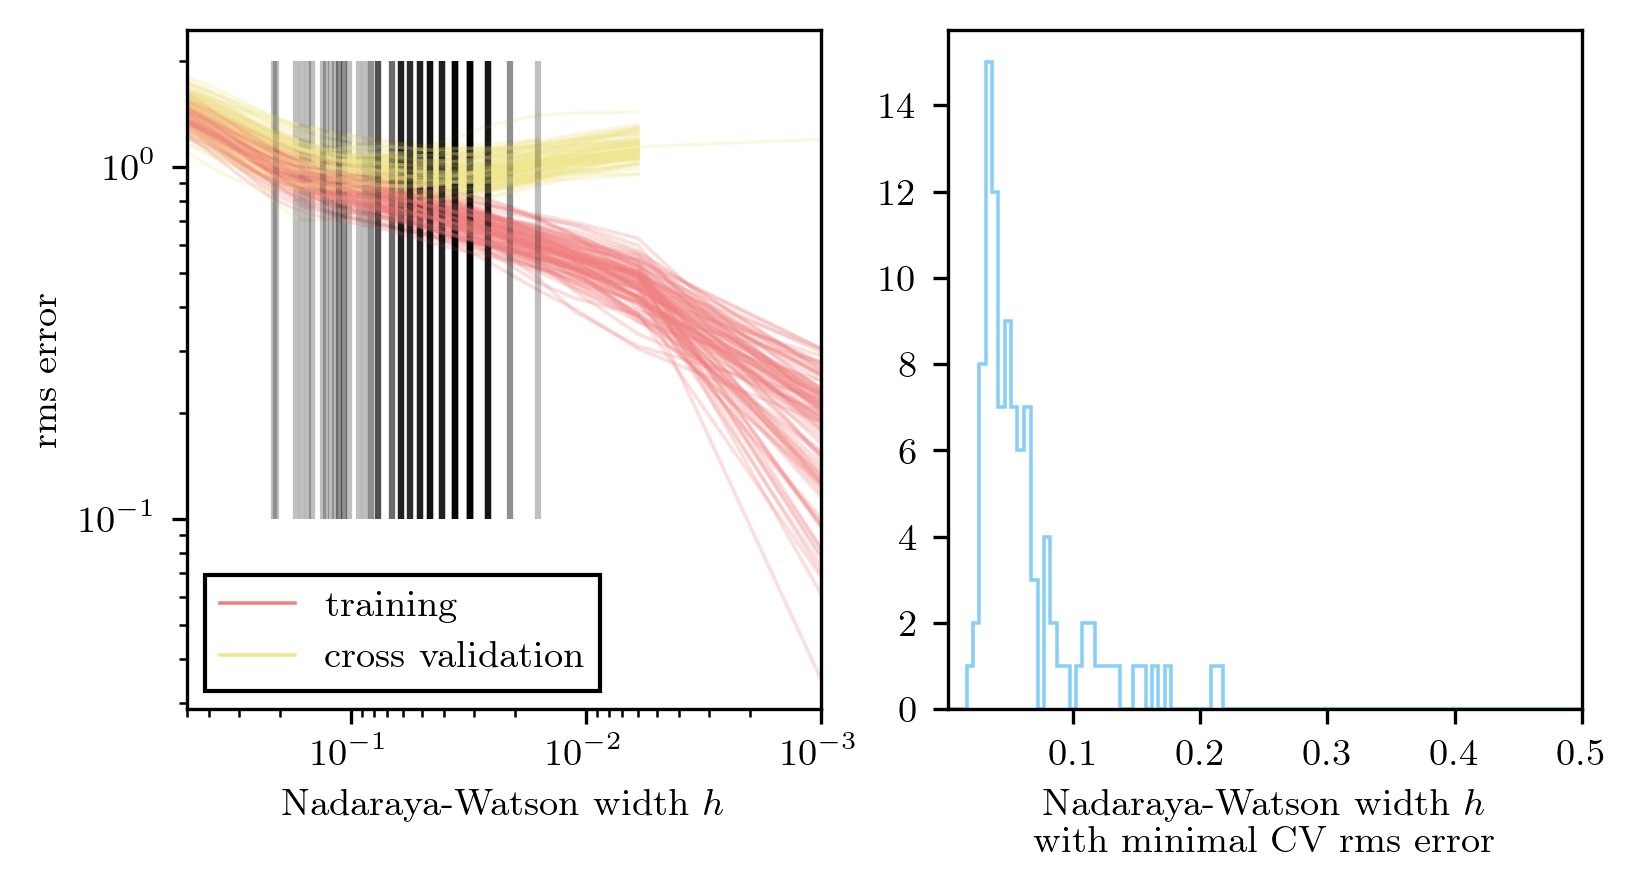

In [ ]:
#-------------------------------------------------------------------------
# Now do the Cross Validation 100 times to compute the best kernel function and n_components
# as the mode (most recurring result) and for this mode, average the best fits
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,2,figsize=(6,3))

ax[0].set_xlabel(r'Nadaraya-Watson width $h$')
ax[0].set_ylabel('rms error')
ax[0].set_xlim(0.5,0.001)
ax[0].set_xscale('log')
# ax[0].set_xticks(np.logspace(-1,0,10))
ax[0].set_yscale('log')
# ax[0].set_ylim(1e-1,1)

ax[1].set_xlim(0.001,0.5)
ax[1].set_xlabel(r'Nadaraya-Watson width $h$'+'\nwith minimal CV rms error')

best_Nadaraya_width_lots = []
mu_grid_Nadaraya_lots = []

Nadaraya_widths = np.round(np.linspace(0.5,0.001,100), 3)

ax[0].plot([], [], lw=0.85, color='lightcoral', label='training')
ax[0].plot([], [], lw=0.85, color='khaki', label='cross validation')

for j in range(100):

    z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample, mu_sample, dmu, test_size=0.65)

    N_train = len(z_train)
    N_test  = len(z_test)

    Nadaraya_regr = []

    for Nadaraya_width in Nadaraya_widths:
        Nadaraya_regr.append(NadarayaWatson(kernel='gaussian', h=Nadaraya_width))

    training_err = np.zeros(len(Nadaraya_widths))
    crossval_err = np.zeros(len(Nadaraya_widths))

    mu_grid_train = []

    for i in range(len(Nadaraya_widths)):

        Nadaraya_regr[i].fit(z_train[:,np.newaxis], mu_train)

        mu_grid_i = Nadaraya_regr[i].predict(z_grid[:,np.newaxis])
        mu_grid_train.append(mu_grid_i)

        mu_train_i = Nadaraya_regr[i].predict(z_train[:,np.newaxis])
        mu_test_i  = Nadaraya_regr[i].predict(z_test[:,np.newaxis])

        training_err[i] = np.sqrt( np.sum( (mu_train_i - mu_train)**2 / N_train) )
        crossval_err[i] = np.sqrt( np.sum( (mu_test_i  - mu_test)**2  / N_test) )
    
    ax[0].plot(Nadaraya_widths, training_err, alpha=0.25, lw=0.85, color='lightcoral')
    ax[0].plot(Nadaraya_widths, crossval_err, alpha=0.25, lw=0.85, color='khaki')

    best_Nadaraya_width = Nadaraya_widths[np.nanargmin(crossval_err)]
    best_Nadaraya_width_lots.append(best_Nadaraya_width)
    
    ax[0].vlines(best_Nadaraya_width, ymin=1e-1, ymax=2, color='black', alpha=0.25)

    best_Nadaraya_regr = NadarayaWatson(kernel='gaussian', h=best_Nadaraya_width)

    # train data only
    best_Nadaraya_regr.fit(z_train[:,np.newaxis], mu_train)
    
    mu_grid_tr = best_Nadaraya_regr.predict(z_grid[:,np.newaxis])
    mu_grid_Nadaraya_lots.append(mu_grid_tr)

_ = fancyhist(best_Nadaraya_width_lots, ax=ax[1], bins=np.round(np.linspace(0.001,0.5,100),3), histtype='step', density=False, color='lightskyblue', lw=0.85) #np.logspace(-2,0,300)

_ = ax[0].legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=3)

print(best_Nadaraya_width_lots)

if False:
    fig.savefig('./L17_images/L17__NadarayaRegr__CrossValidation.pdf', bbox_inches='tight')
    fig.savefig('./L17_images/L17__NadarayaRegr__CrossValidation.png', bbox_inches='tight')

#-------------------------------------------------------------------------

In [ ]:
best_Nadaraya = stats.mode(best_Nadaraya_width_lots).mode[0]     # weird syntax but ok
print(best_Nadaraya)
# best_Nadaraya = np.nanmedian(best_Nadaraya_width_lots)
# print(best_Nadaraya)

#-------------------------------------------------------------------------
# Organize results from multiple cross validations

print('The best Nadaraya-Watson bandwidth = {:.3f}'.format(best_Nadaraya))

best_Nadaraya_width_lots = np.array(best_Nadaraya_width_lots)
print(best_Nadaraya_width_lots.shape)

mu_grid_Nadaraya_lots = np.array(mu_grid_Nadaraya_lots)
print(mu_grid_Nadaraya_lots.shape)

#-------------------------------------------------------------------------
# select only the training-validation splits with N_polynomial_best=2

index_Nadaraya = best_Nadaraya_width_lots == best_Nadaraya
print(index_Nadaraya)
N_best_Nadaraya = len(best_Nadaraya_width_lots[index_Nadaraya])
print('The number of fits we have done with bandwidth = {:.3f} is {:d}'.format(best_Nadaraya, N_best_Nadaraya))

mu_grid_Nadaraya_onlybest = np.copy(mu_grid_Nadaraya_lots[index_Nadaraya,:])
print(mu_grid_Nadaraya_onlybest.shape)

mu_grid_Nadaraya_onlybest_avg = np.average(mu_grid_Nadaraya_onlybest, axis=0)
print(mu_grid_Nadaraya_onlybest_avg.shape)

#-------------------------------------------------------------------------


0.031
The best Nadaraya-Watson bandwidth = 0.031
(100,)
(100, 1000)
[False False  True False False False False False False False False False
 False  True False  True False False  True False False False False False
  True False  True False False False  True  True False False False False
 False False False False False False False False False  True False  True
 False False False  True False False False False False False  True False
 False False  True False False False False False False False  True False
 False False False False False False  True False False False False False
 False False False False False False False False False False False False
 False False False False]
The number of fits we have done with bandwidth = 0.031 is 15
(15, 1000)
(1000,)


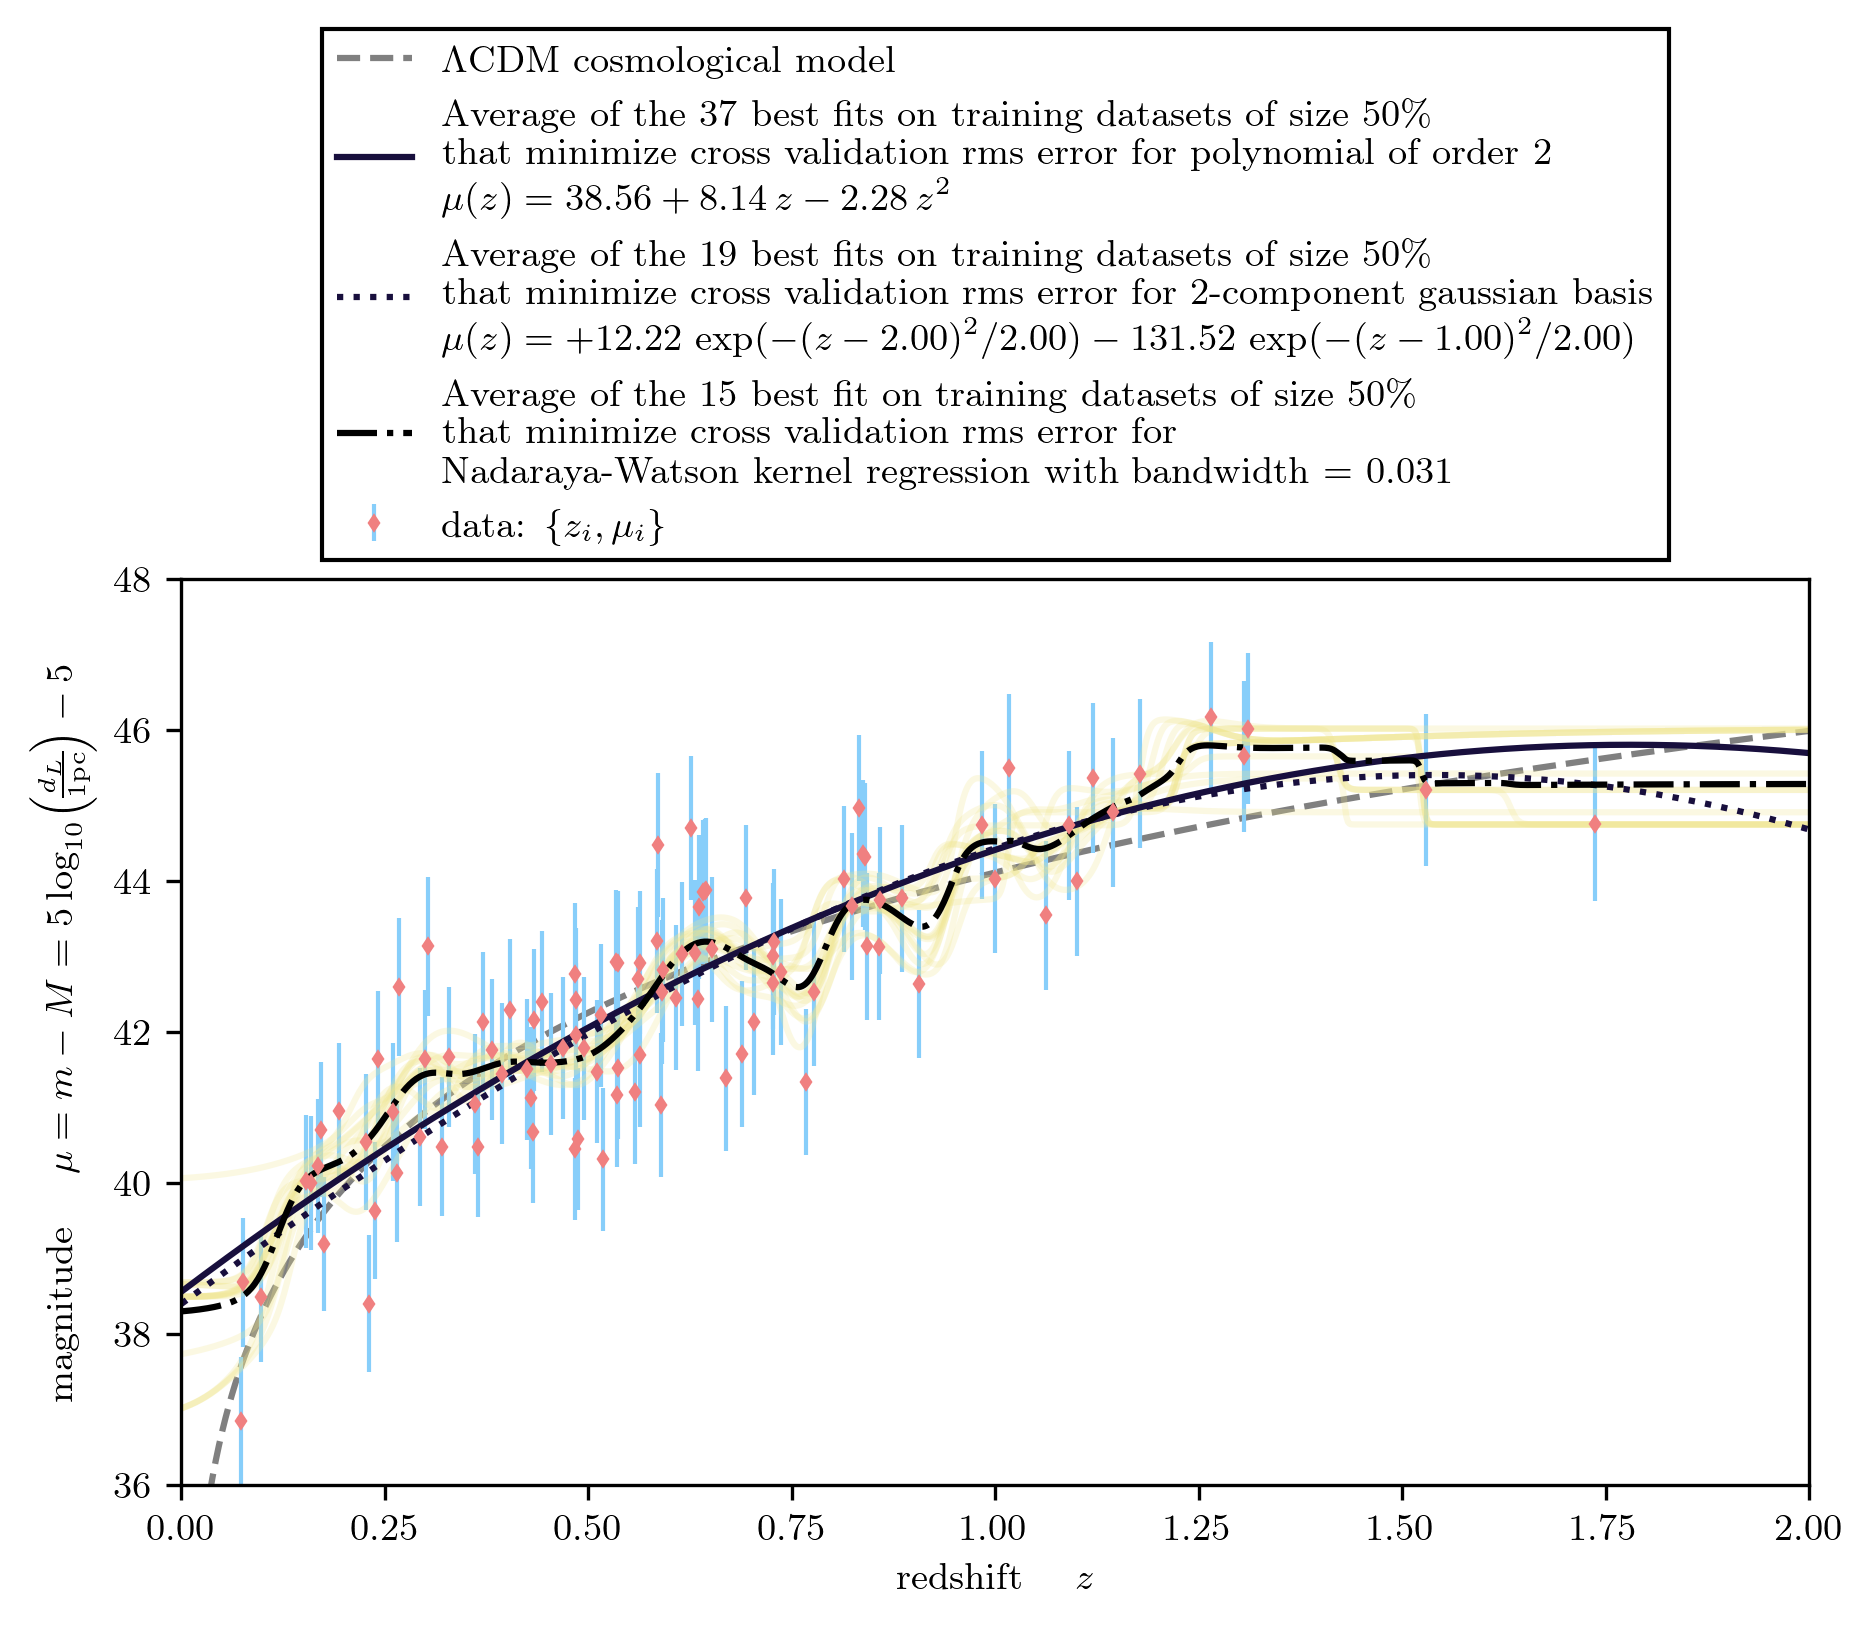

In [ ]:
#-------------------------------------------------------------------------
# finally plot the best fit curve as average of the cross validated models
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(7,4))

ax.plot(z_grid, mu_true, color='gray', label='$\Lambda$CDM cosmological model', ls='--')

ax.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data: $\{z_i, \mu_i\}$')

ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

for i in range(N_best_Nadaraya):
    ax.plot(z_grid, mu_grid_Nadaraya_onlybest[i,:], color='khaki', alpha=0.25) 

ax.plot(z_grid, mu_grid_onlybest_avg, color=color1ist[best_deg_CV-1], label=labellina) 

ax.plot(z_grid, mu_grid_basis_onlybest_avg, color=color1ist[best_deg_basis-1], ls=':', label=labellina_basis) 

labellina_Nadaraya = 'Average of the {:d} best fit on training datasets of size 50\%\n'.format(N_best_Nadaraya)
labellina_Nadaraya += 'that minimize cross validation rms error for\n'
labellina_Nadaraya += 'Nadaraya-Watson kernel regression with bandwidth = {:.3f}'.format(best_Nadaraya)
ax.plot(z_grid, mu_grid_Nadaraya_onlybest_avg, color='black', ls='-.', label=labellina_Nadaraya) 

_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc='lower center',bbox_to_anchor=(0.5,1.0)) #,bbox_to_anchor=(0.75,0))

if False:
    fig.savefig('./L17_images/L17__NadarayaRegr__Best_Fit_CrossValidated.pdf', bbox_inches='tight')
    fig.savefig('./L17_images/L17__NadarayaRegr__Best_Fit_CrossValidated.png', bbox_inches='tight')

#-------------------------------------------------------------------------

In [ ]:
_ = '''lin_reg = LinearRegression()
lin_reg.fit(z_sample[:,np.newaxis], mu_sample, dmu)
# theta0 = lin_reg.intercept_
# theta0, theta1 = lin_reg.coef_
# mu_pred_LR = lin_reg.predict(z_test[:,np.newaxis])
 
N = len(z_sample)
N_train = int( 0.5 * N )

rng = default_rng()
indexes = rng.choice(N, size=N_train, replace=False)
indexes_not = 
print(indexes)

z_train = z_sample[indexes]
'''